# Fault Converters Visualization Studio

This notebook provides interactive visualizations of the transfer functions across different component variations, and explores the results of the KerasTuner hyperparameter search.

In [1]:
import os
import sys

sys.path.append(os.path.abspath(".."))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.visualization.analysis import (
    extract_single_component_anomalies,
    plot_component_anomalies,
    parse_kerastuner_results,
    plot_hyperparameter_comparison,
    plot_model_hp_search,
    plot_metrics_comparison,
    plot_threshold_comparison,
    plot_confusion_matrix_from_counts,
    plot_component_error_analysis,
    plot_error_by_deviation_magnitude,
    plot_error_by_variation_count,
    plot_prediction_score_distribution,
    plot_error_scatter,
)

OUTPUT_DIR = Path("../docs/plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

I0000 00:00:1776271110.996806  918699 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Single Component Variation Analysis
This section automatically identifies components with independent anomaly variations, plots their transfer functions over different deviations, and saves them to `docs/plots/`.

2026-04-15 18:38:52 | src.visualization.analysis | INFO | Scanning ../data/buck/buck_data for single-component variations...
Found 5 varying components: Esr_C, Esr_L, Rds_2, Rds_1, Cout

--- Esr_C Variations ---
2026-04-15 18:38:55 | src.visualization.analysis | INFO | Plot saved to ../docs/plots/anomaly_deviation_Esr_C.png


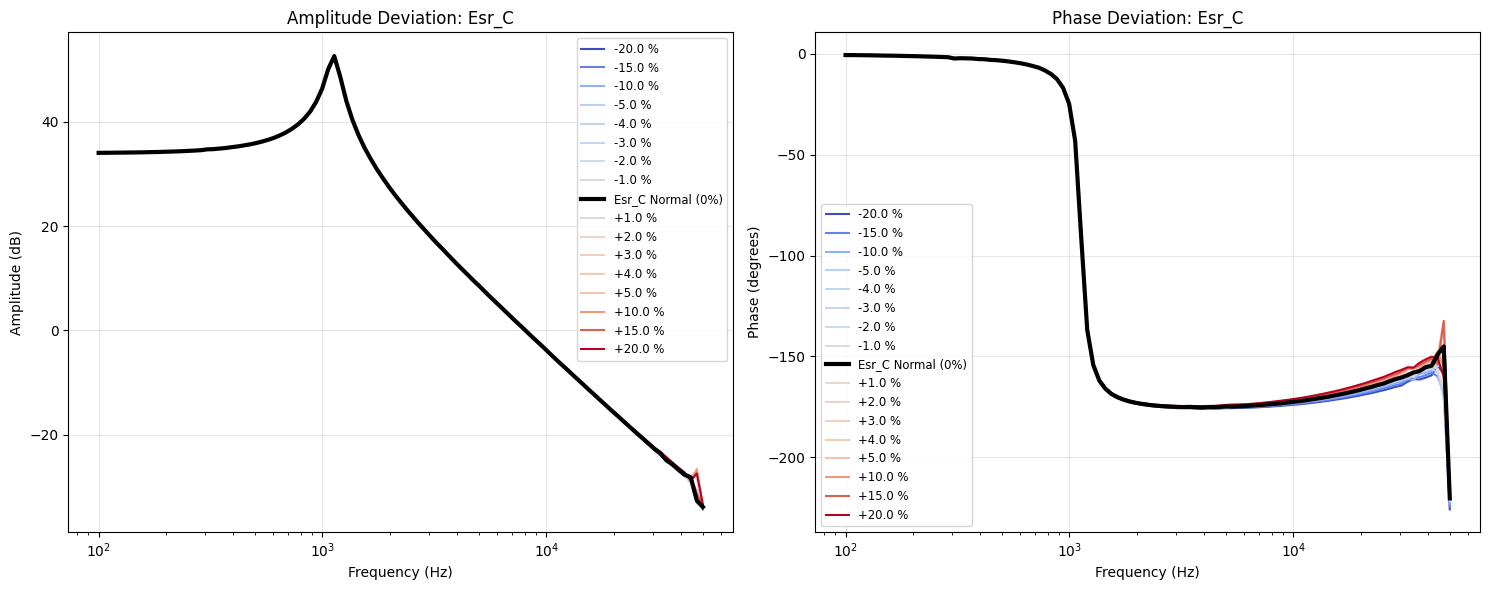


--- Esr_L Variations ---
2026-04-15 18:38:57 | src.visualization.analysis | INFO | Plot saved to ../docs/plots/anomaly_deviation_Esr_L.png


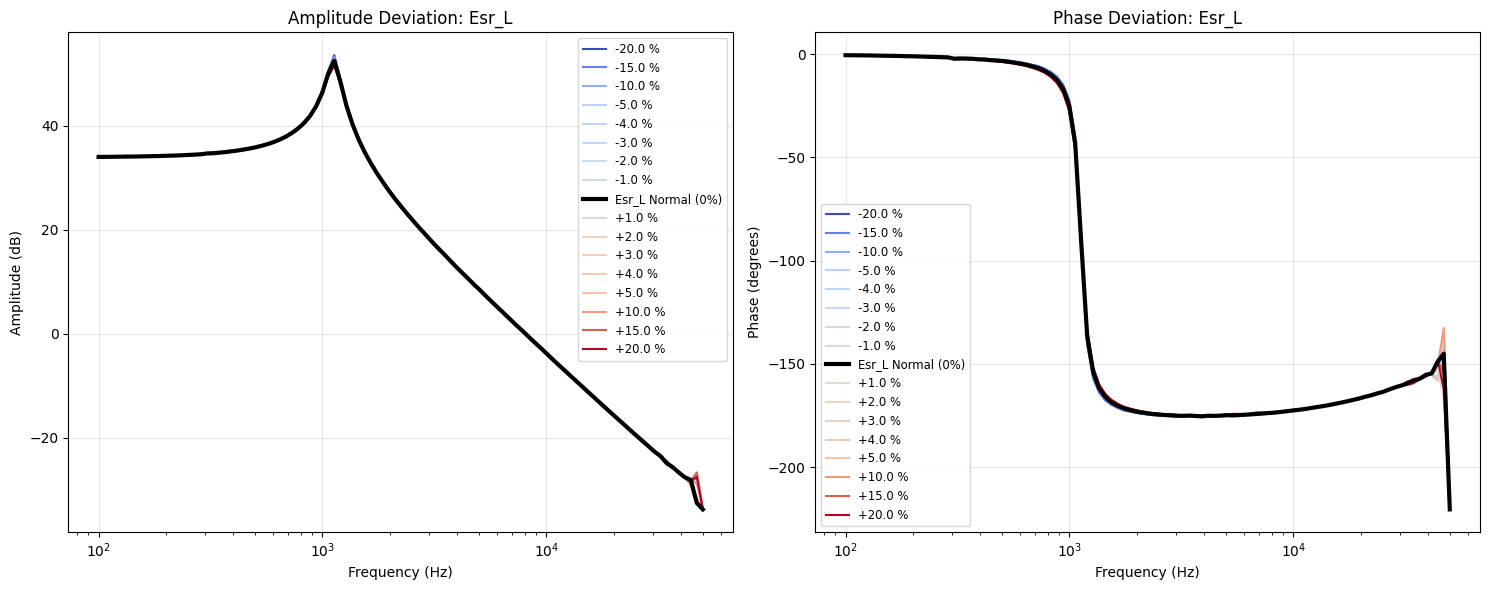


--- Rds_2 Variations ---
2026-04-15 18:38:58 | src.visualization.analysis | INFO | Plot saved to ../docs/plots/anomaly_deviation_Rds_2.png


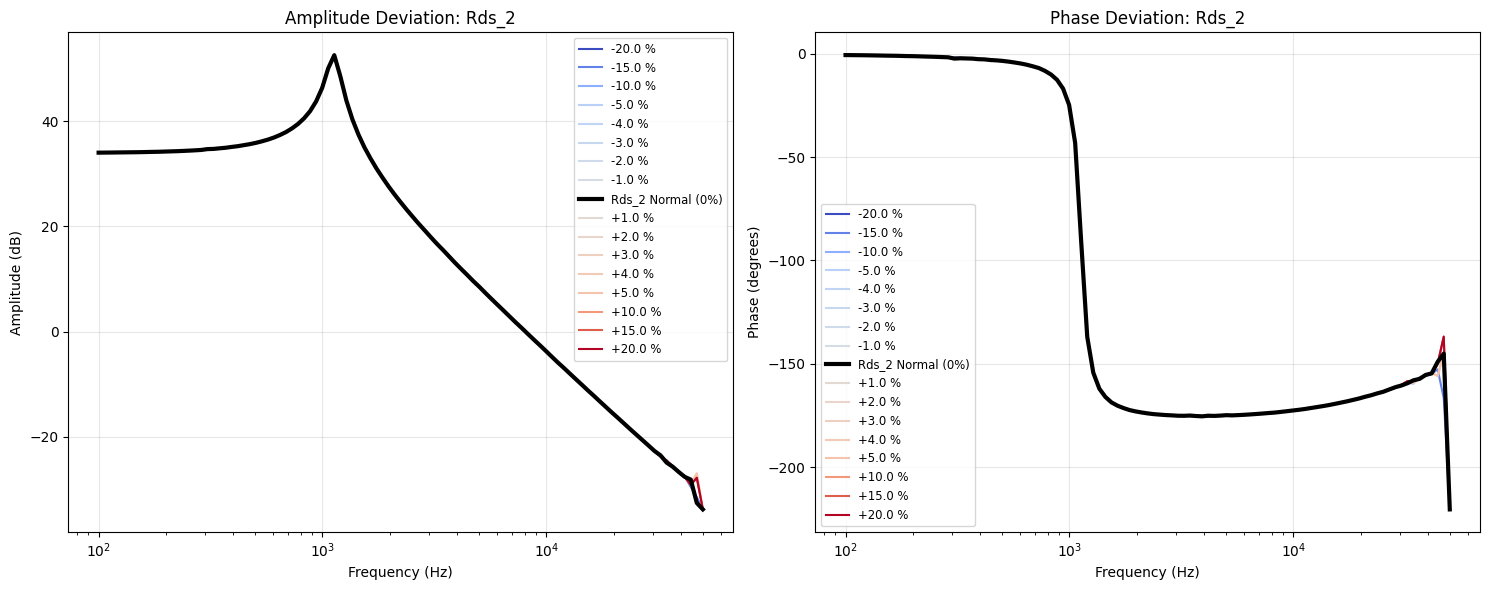


--- Rds_1 Variations ---
2026-04-15 18:39:00 | src.visualization.analysis | INFO | Plot saved to ../docs/plots/anomaly_deviation_Rds_1.png


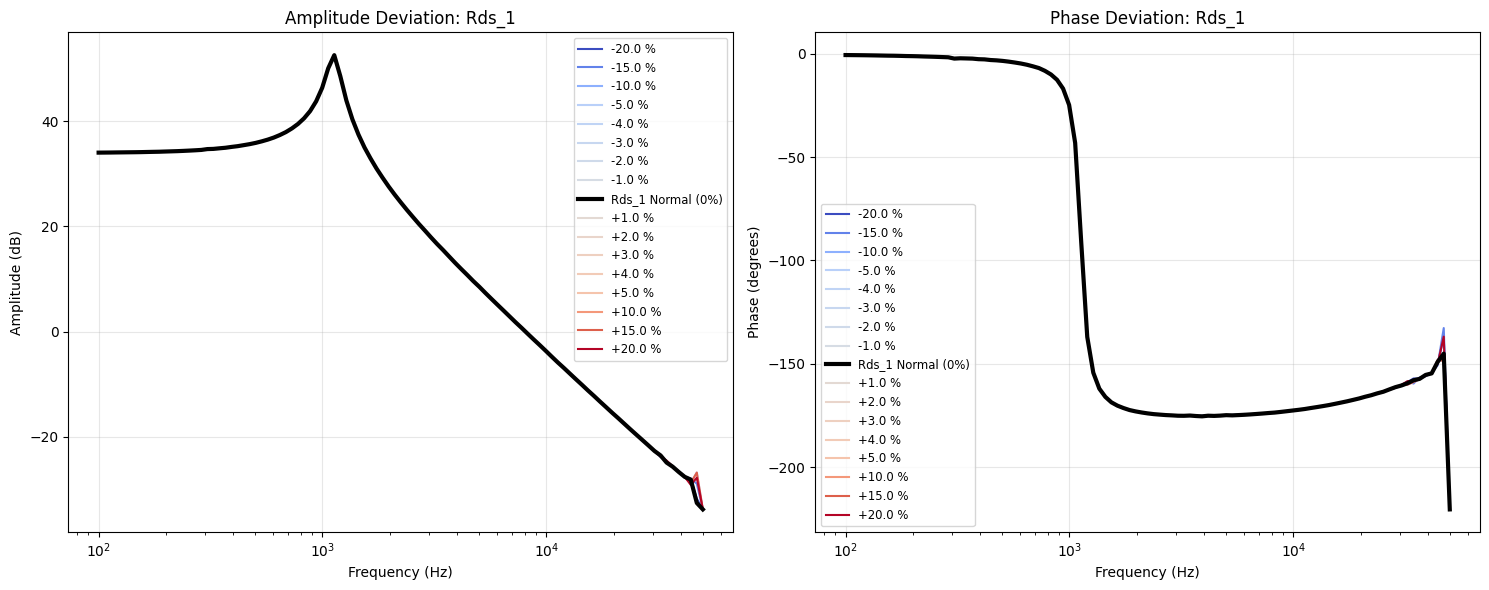


--- Cout Variations ---
2026-04-15 18:39:02 | src.visualization.analysis | INFO | Plot saved to ../docs/plots/anomaly_deviation_Cout.png


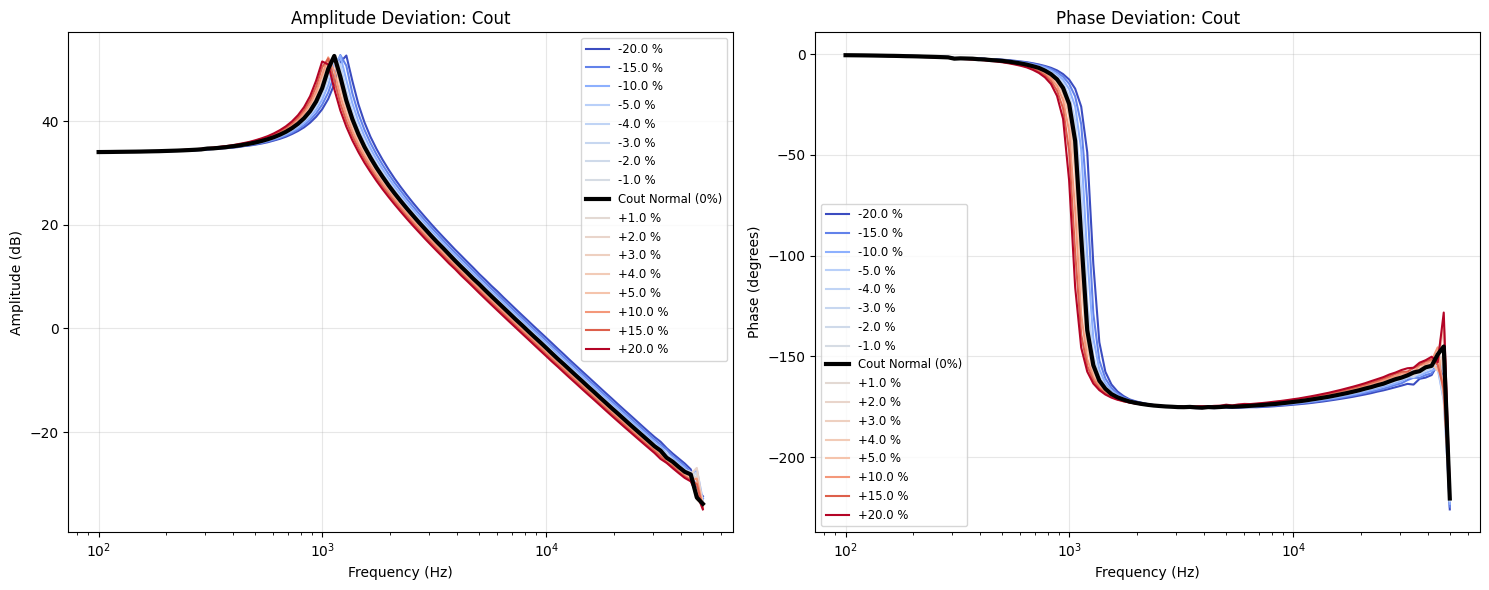

In [2]:
DATA_DIR = Path("../data/buck/buck_data")

variations = extract_single_component_anomalies(DATA_DIR)
print(f"Found {len(variations)} varying components: {', '.join(variations.keys())}")

for comp, paths in variations.items():
    print(f"\n--- {comp} Variations ---")
    plot_path = OUTPUT_DIR / f"anomaly_deviation_{comp}.png"
    fig = plot_component_anomalies(comp, paths, save_path=plot_path, show_plot=True)

## 2. Hyperparameter Search Results
Extract and compare KerasTuner `trial.json` files generated for different Autoencoder models. Generates scatter plots for individual hyperparameter mappings and an aggregated final model comparison scatter plot, saving the results to `docs/plots/`.

In [3]:
EXPERIMENTS_DIR = Path("../experiments")

hp_results = parse_kerastuner_results(EXPERIMENTS_DIR)

if hp_results:
    # 1. Scatter plots for individual models
    for model, trials in hp_results.items():
        print(f"\n--- {model} HP Search ({len(trials)} trials) ---")
        model_plot_path = OUTPUT_DIR / f"hp_search_{model}.png"
        fig = plot_model_hp_search(
            model, trials, save_path=model_plot_path, show_plot=True
        )

    # 2. Final model comparisons
    print("\n--- Final Model Comparisons ---")
    plot_path = OUTPUT_DIR / "hyperparameter_comparison.png"
    fig_comparison = plot_hyperparameter_comparison(
        hp_results, save_path=plot_path, show_plot=True
    )
else:
    print("No KerasTuner trials found or EXPERIMENTS_DIR path is incorrect.")

No KerasTuner trials found or EXPERIMENTS_DIR path is incorrect.


### 2.2 Unified Hyperparameter Search Landscape
Consolidates the hyperparameter search into a single plot using color, size, and style to distinguish between different hyperparameters.

## 3. Final Model Evaluation & Comparison
This section extracts final model performance metrics from `metrics.json` files and creates comparative visualizations.

--- Metrics Comparison ---
2026-04-15 18:39:04 | src.visualization.analysis | INFO | Comparison plot saved to ../docs/plots/final_metrics_comparison.png


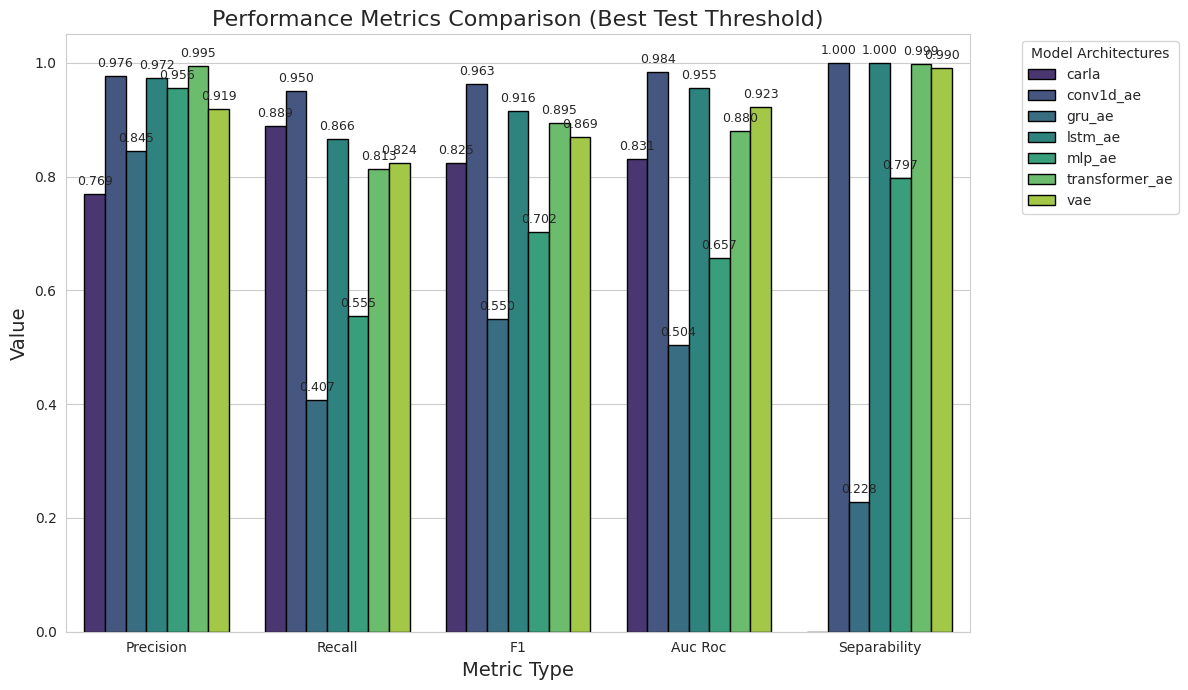


--- Individual Confusion Matrices ---
2026-04-15 18:39:04 | src.visualization.analysis | INFO | Confusion matrix for carla saved to ../docs/plots/confusion_matrix_carla.png


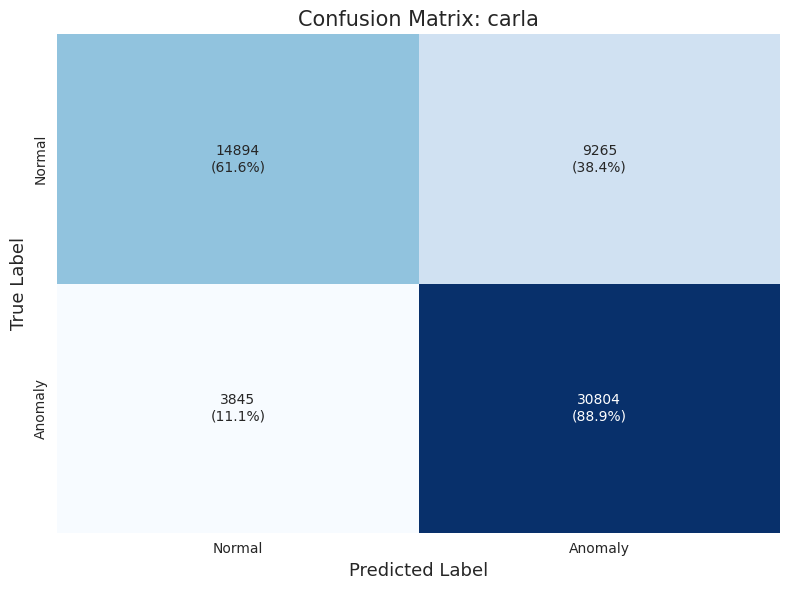

2026-04-15 18:39:05 | src.visualization.analysis | INFO | Confusion matrix for conv1d_ae saved to ../docs/plots/confusion_matrix_conv1d_ae.png


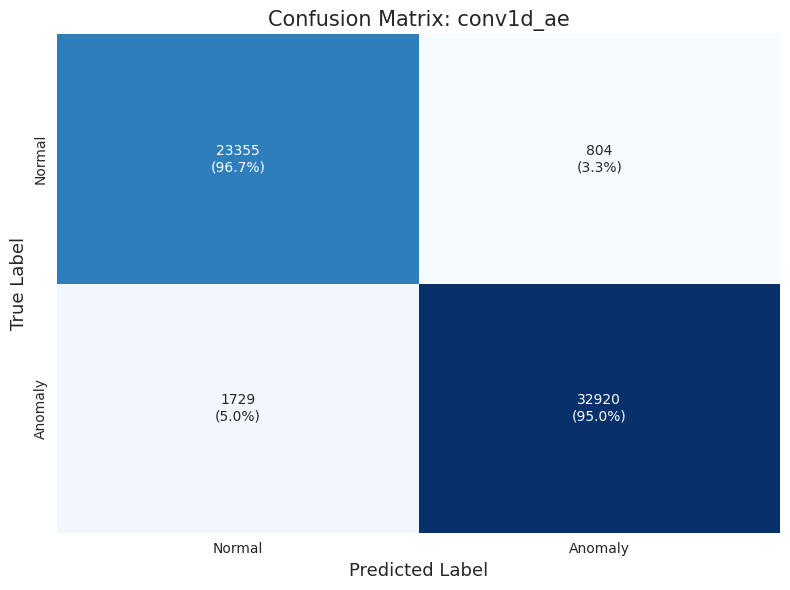

2026-04-15 18:39:05 | src.visualization.analysis | INFO | Confusion matrix for gru_ae saved to ../docs/plots/confusion_matrix_gru_ae.png


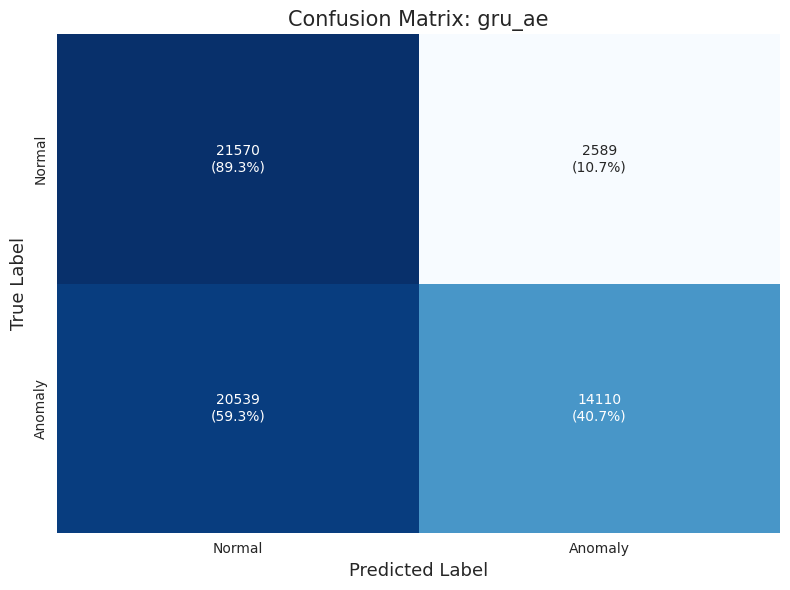

2026-04-15 18:39:06 | src.visualization.analysis | INFO | Confusion matrix for lstm_ae saved to ../docs/plots/confusion_matrix_lstm_ae.png


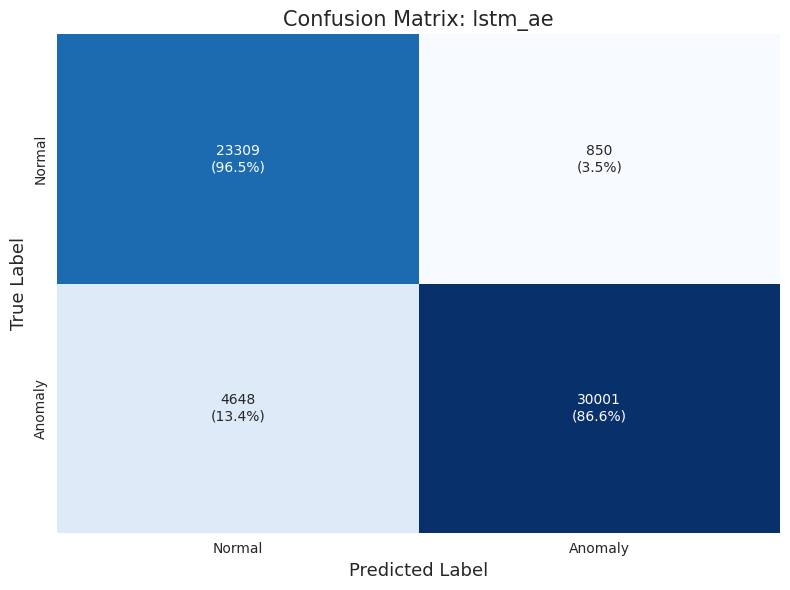

2026-04-15 18:39:06 | src.visualization.analysis | INFO | Confusion matrix for mlp_ae saved to ../docs/plots/confusion_matrix_mlp_ae.png


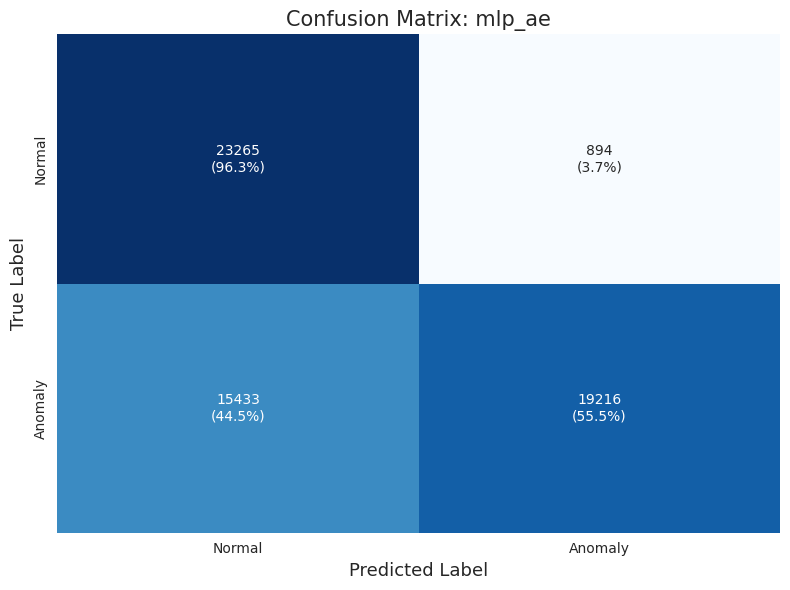

2026-04-15 18:39:07 | src.visualization.analysis | INFO | Confusion matrix for transformer_ae saved to ../docs/plots/confusion_matrix_transformer_ae.png


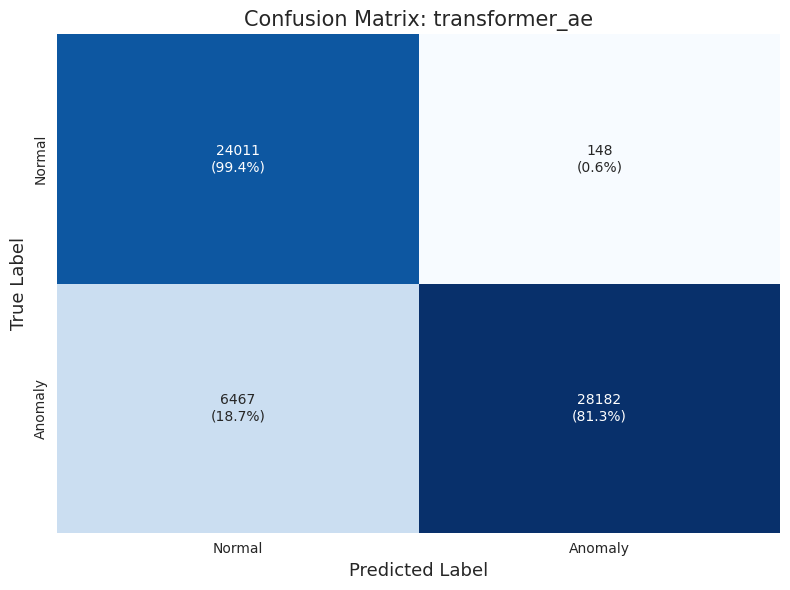

2026-04-15 18:39:07 | src.visualization.analysis | INFO | Confusion matrix for vae saved to ../docs/plots/confusion_matrix_vae.png


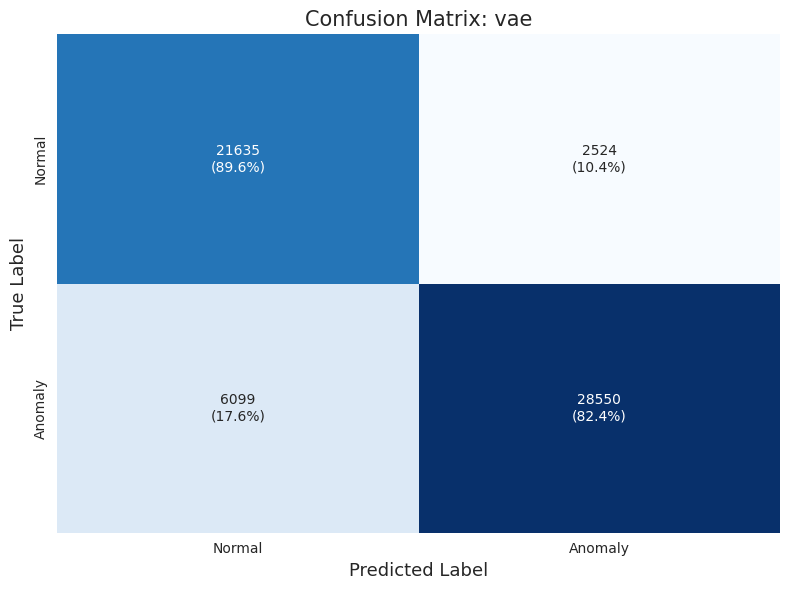

In [4]:
import json
import pandas as pd

all_metrics = {}

for model_dir in EXPERIMENTS_DIR.iterdir():
    if not model_dir.is_dir():
        continue

    metrics_path = model_dir / "metrics.json"
    config_path = model_dir / "model_config.json"

    if metrics_path.exists():
        try:
            with open(metrics_path, "r") as f:
                metrics = json.load(f)

            model_name = model_dir.name
            if config_path.exists():
                try:
                    with open(config_path, "r") as f:
                        config = json.load(f)
                        model_name = config.get("name", model_name)
                except:
                    pass

            all_metrics[model_name] = metrics
        except Exception as e:
            print(f"Could not load {metrics_path}: {e}")

if all_metrics:
    # 1. Plot comparison
    print("--- Metrics Comparison ---")
    plot_path = OUTPUT_DIR / "final_metrics_comparison.png"
    fig_metrics = plot_metrics_comparison(
        all_metrics, save_path=plot_path, show_plot=True
    )

    # 2. Plot Confusion Matrices
    print("\n--- Individual Confusion Matrices ---")
    for model_name, metrics in all_metrics.items():
        cm_plot_path = OUTPUT_DIR / f"confusion_matrix_{model_name}.png"
        fig_cm = plot_confusion_matrix_from_counts(
            metrics, model_name, save_path=cm_plot_path, show_plot=True
        )
else:
    print("No metrics.json files found in experiments directory.")
    # 1. Plot comparison (Best Test Set Performance)
    print("--- Metrics Comparison (Best Threshold per Model) ---")
    plot_path = OUTPUT_DIR / "final_metrics_comparison.png"
    fig_metrics = plot_metrics_comparison(
        all_metrics, save_path=plot_path, show_plot=True
    )

    # 2. Plot Threshold selection analysis
    print("\n--- Threshold Method Comparison ---")
    plot_thresh_path = OUTPUT_DIR / "threshold_method_comparison.png"
    fig_thresh = plot_threshold_comparison(
        all_metrics, target_metric="f1", save_path=plot_thresh_path, show_plot=True
    )

    # 3. Plot Confusion Matrices

## 4. Diagnostic Error Analysis
Deep dive into model failures by analyzing False Positives (FP) and False Negatives (FN) across various component deviations.

Scanning for all trained results...

##############################
# DIAGNOSING: CARLA
##############################

--- [ carla ] Component Error Analysis ---


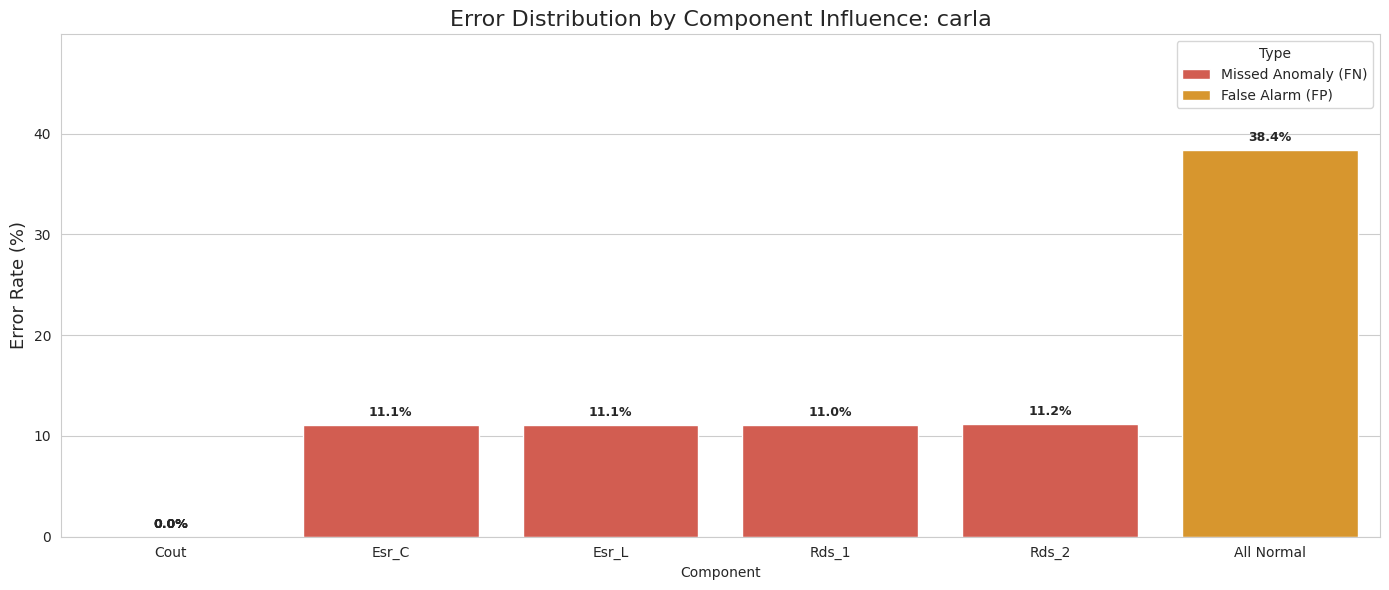


--- [ carla ] Error by Deviation Magnitude ---


<Figure size 640x480 with 0 Axes>

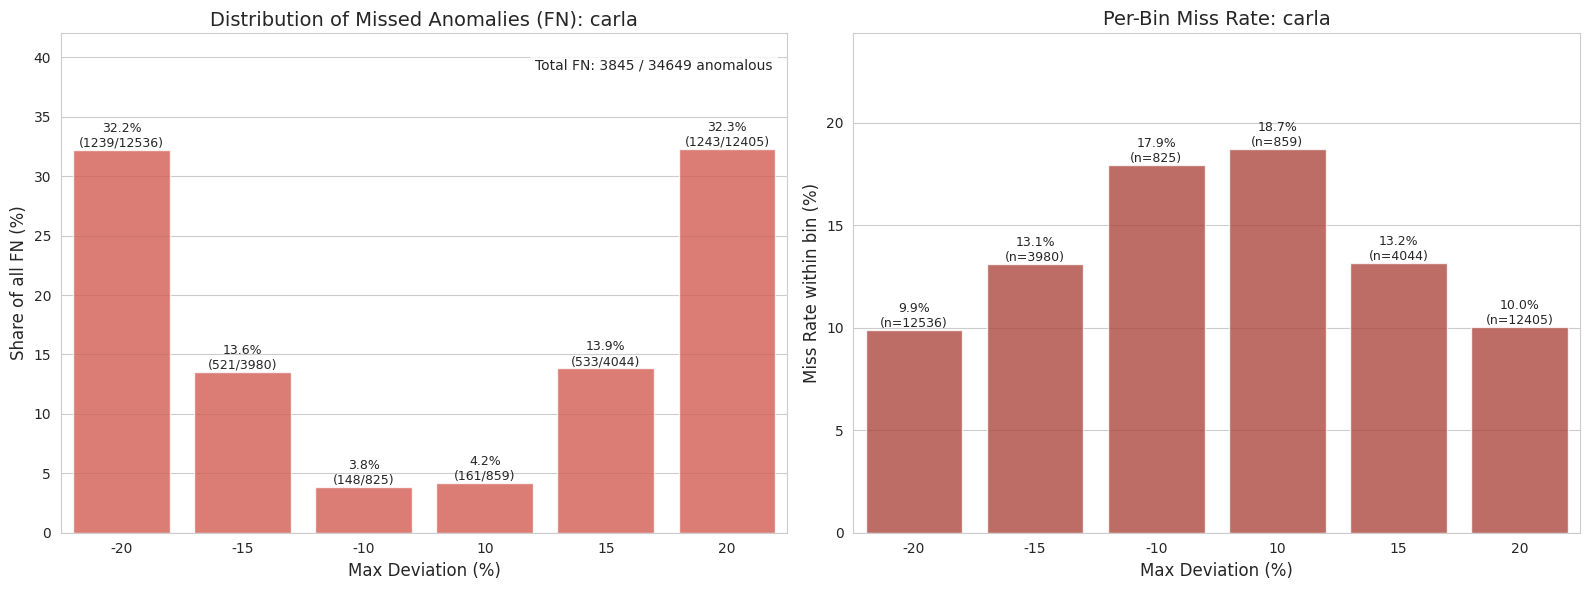


--- [ carla ] Error by Variation Count ---


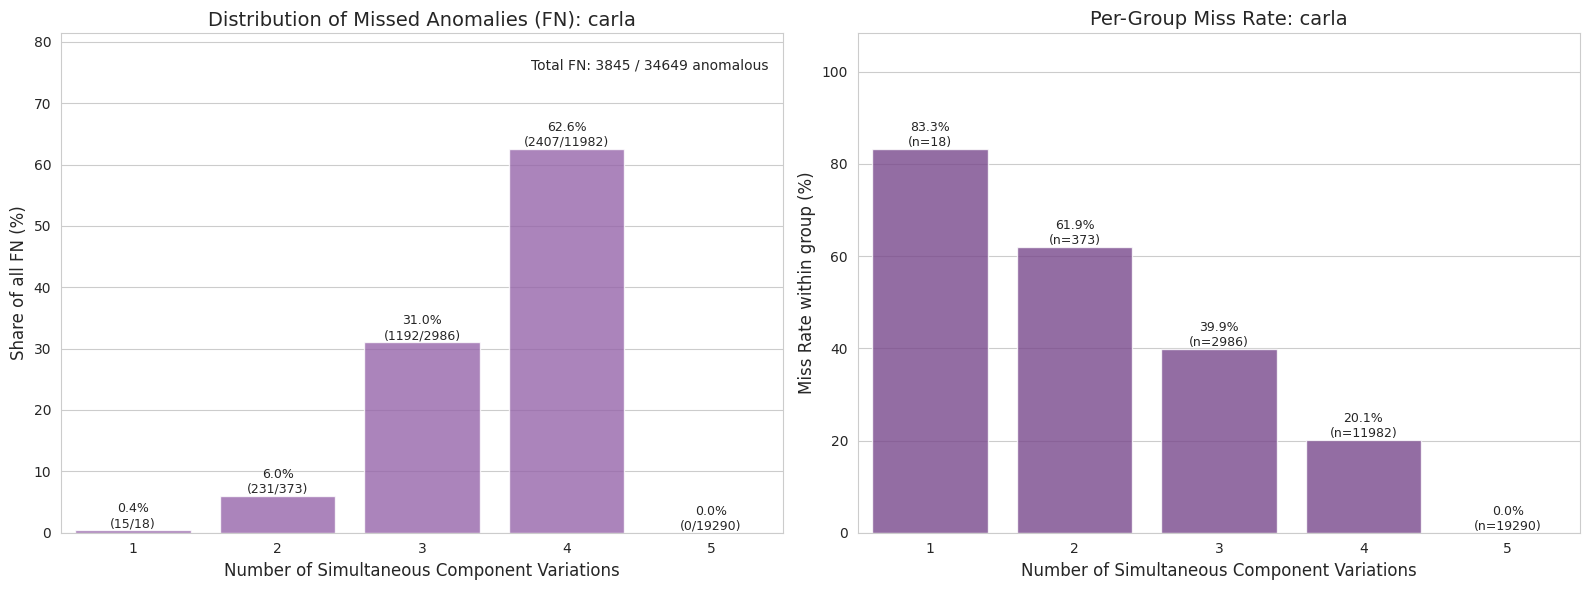


--- [ carla ] Prediction Score Distribution ---


/mnt/e/Work/UC3M/UC3M/fault_converters/src/visualization/analysis.py:947: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


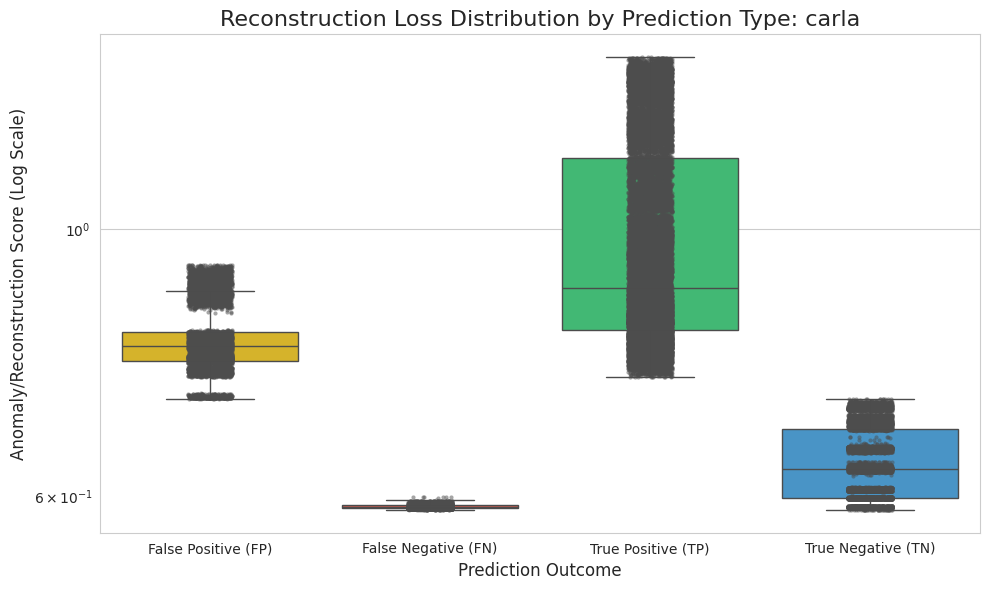


--- [ carla ] Error Scatter Profile ---


<Figure size 640x480 with 0 Axes>

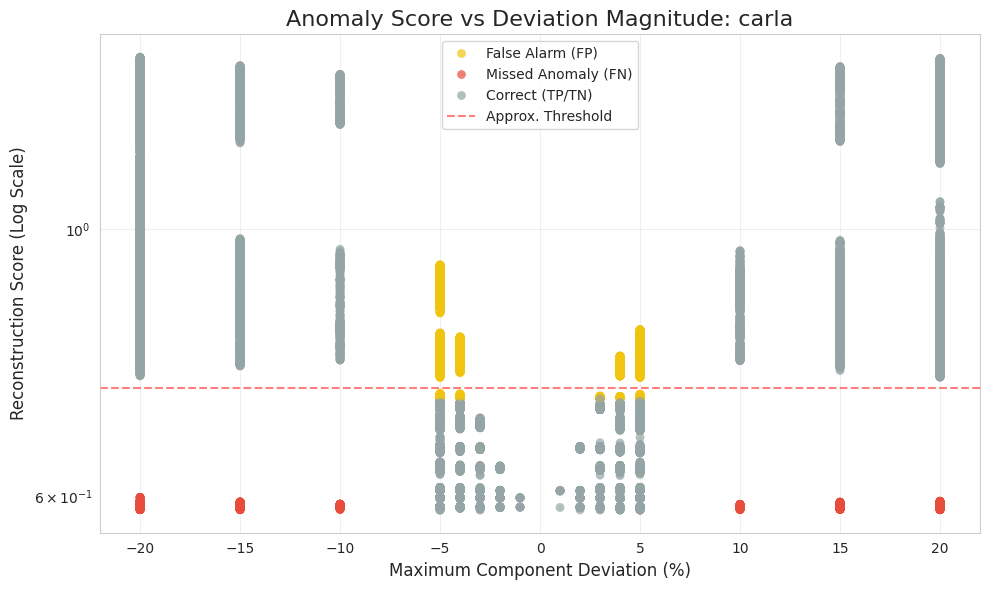


##############################
# DIAGNOSING: CONV1D_AE
##############################

--- [ conv1d_ae ] Component Error Analysis ---


<Figure size 640x480 with 0 Axes>

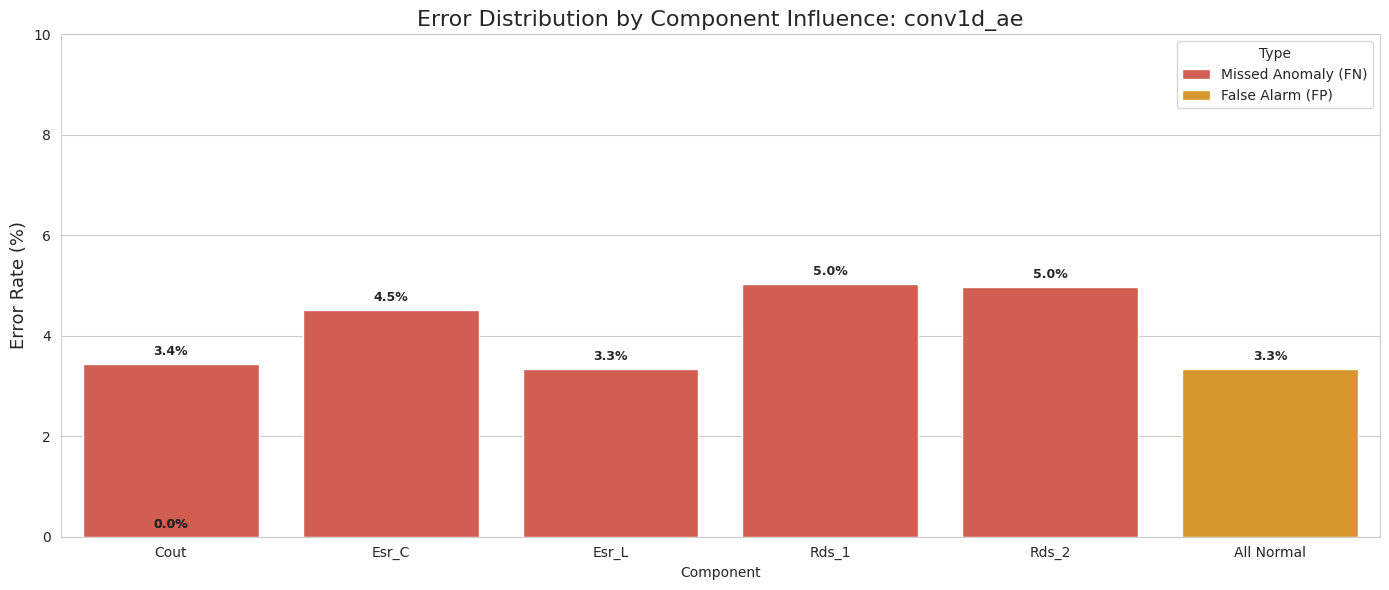


--- [ conv1d_ae ] Error by Deviation Magnitude ---


<Figure size 640x480 with 0 Axes>

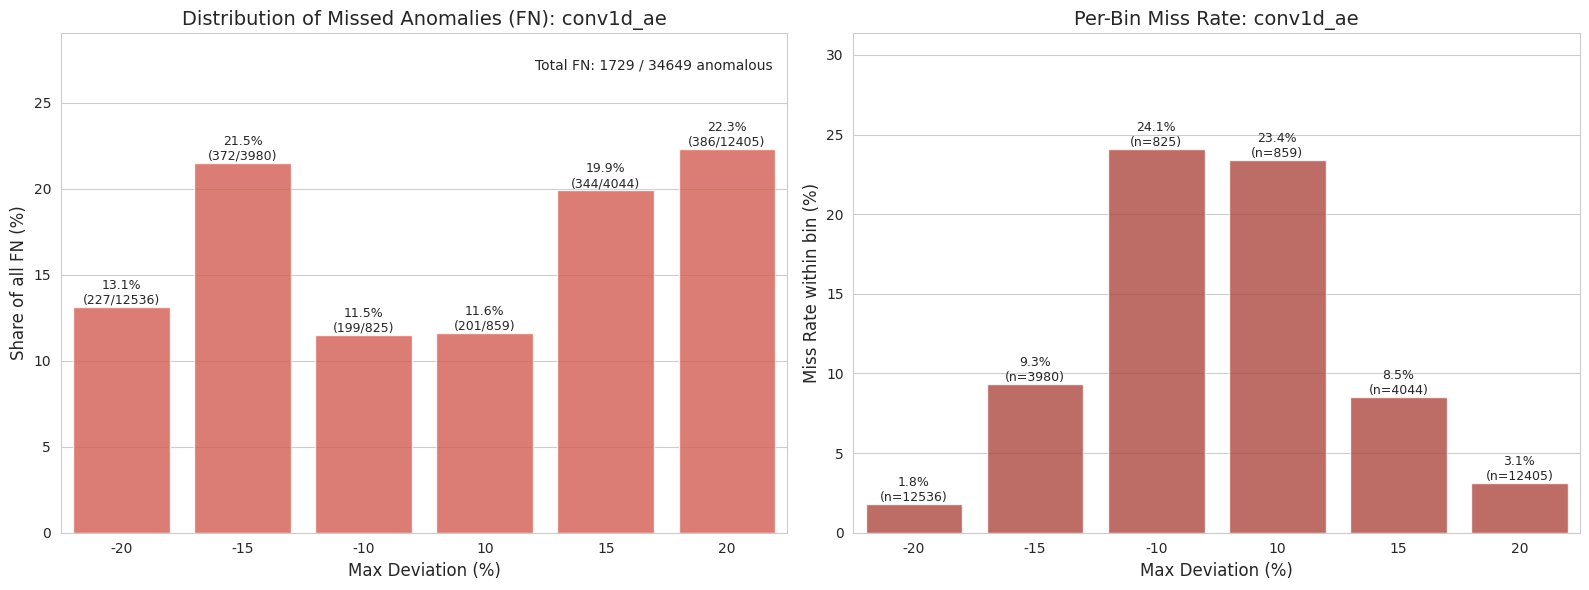


--- [ conv1d_ae ] Error by Variation Count ---


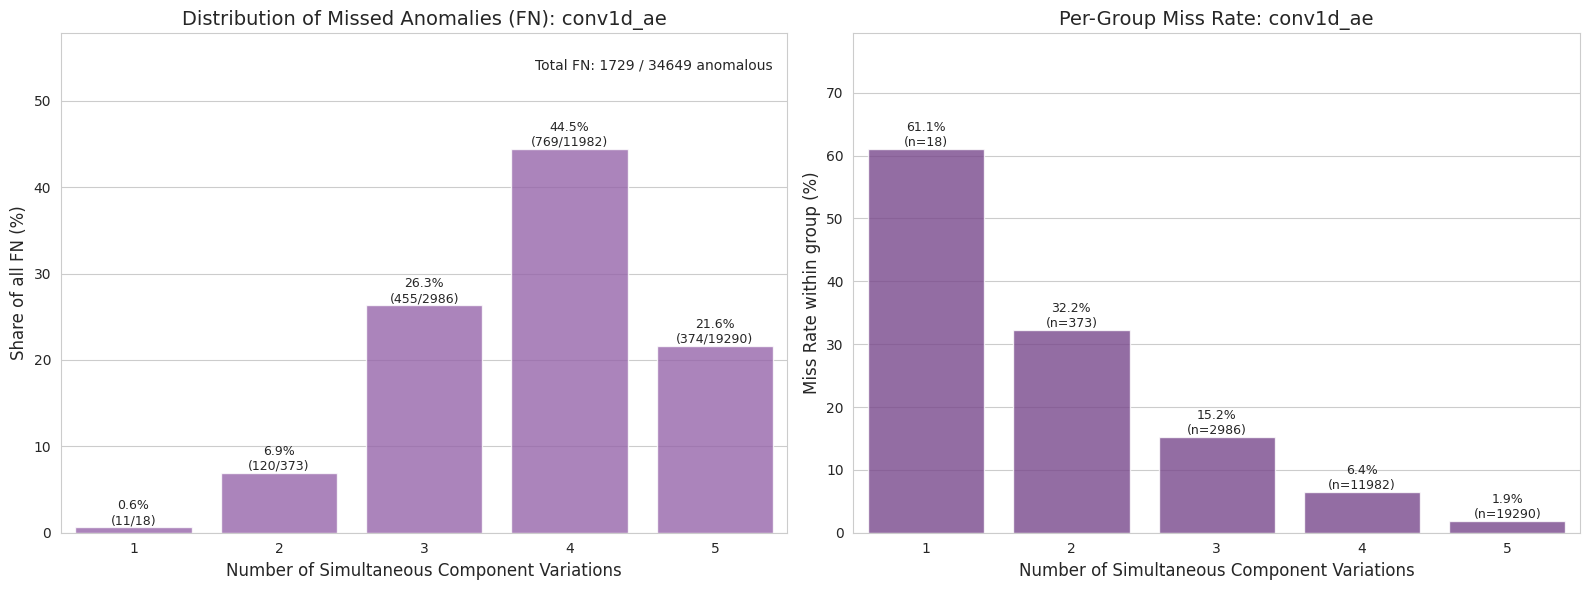


--- [ conv1d_ae ] Prediction Score Distribution ---


/mnt/e/Work/UC3M/UC3M/fault_converters/src/visualization/analysis.py:947: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


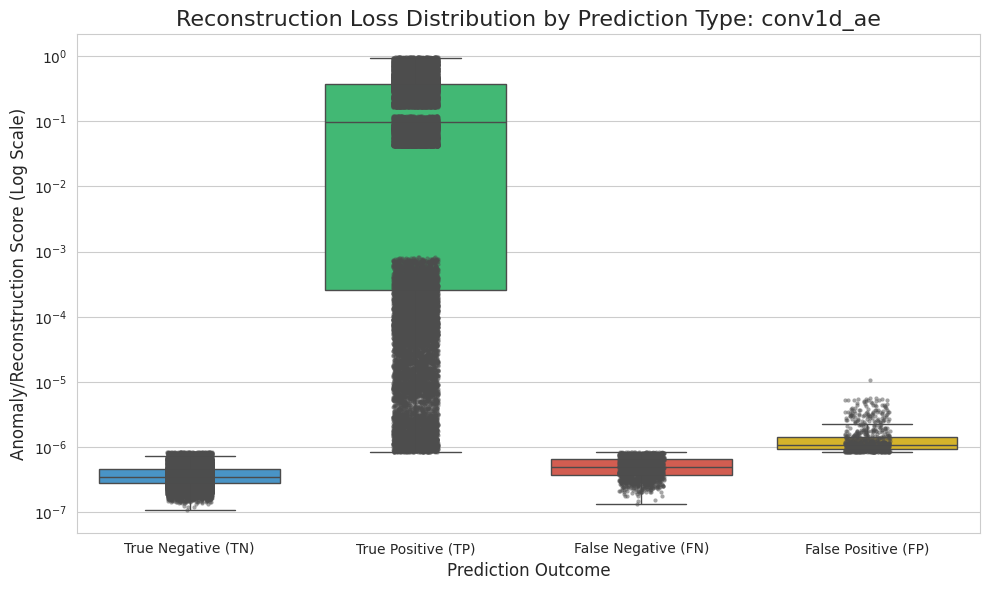


--- [ conv1d_ae ] Error Scatter Profile ---


<Figure size 640x480 with 0 Axes>

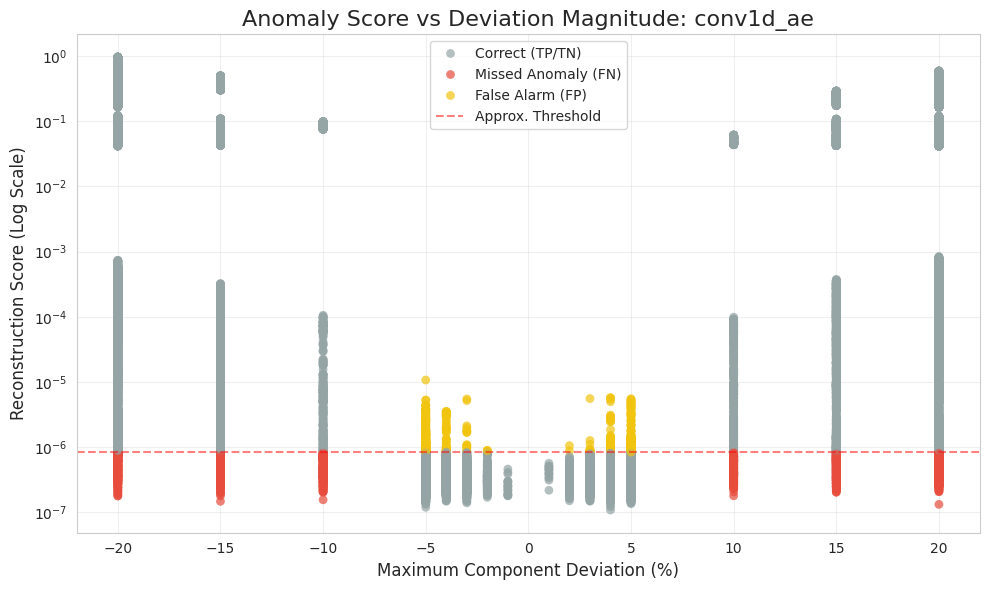


##############################
# DIAGNOSING: GRU_AE
##############################

--- [ gru_ae ] Component Error Analysis ---


<Figure size 640x480 with 0 Axes>

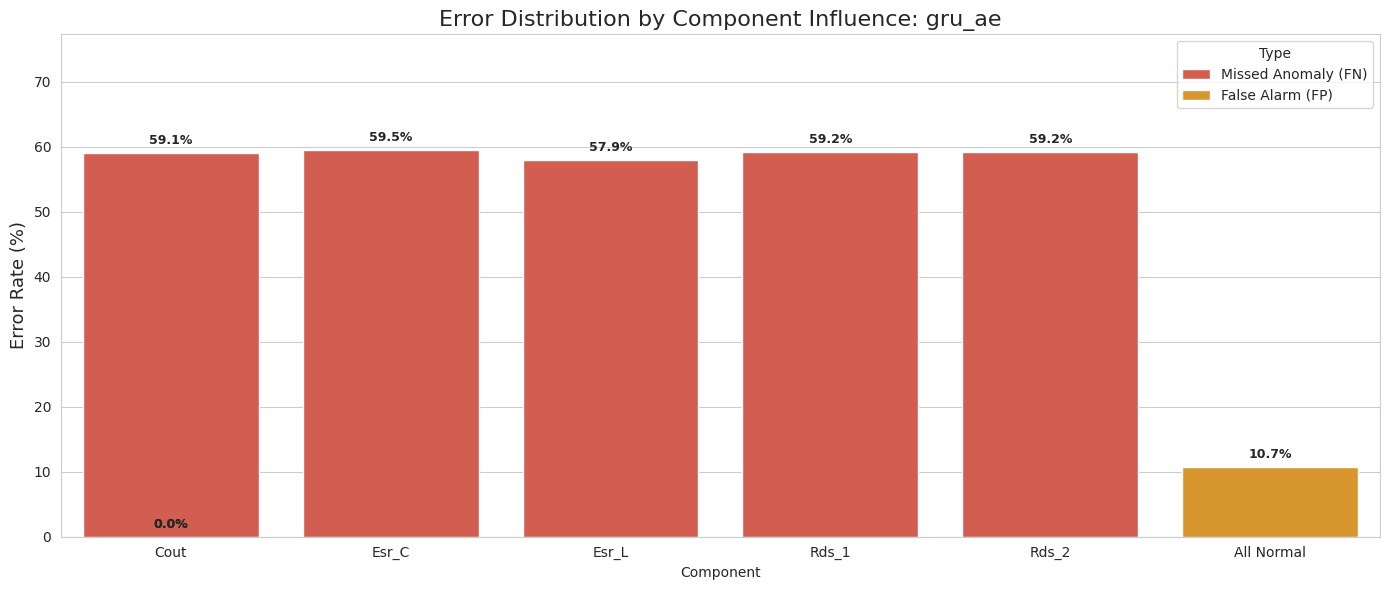


--- [ gru_ae ] Error by Deviation Magnitude ---


<Figure size 640x480 with 0 Axes>

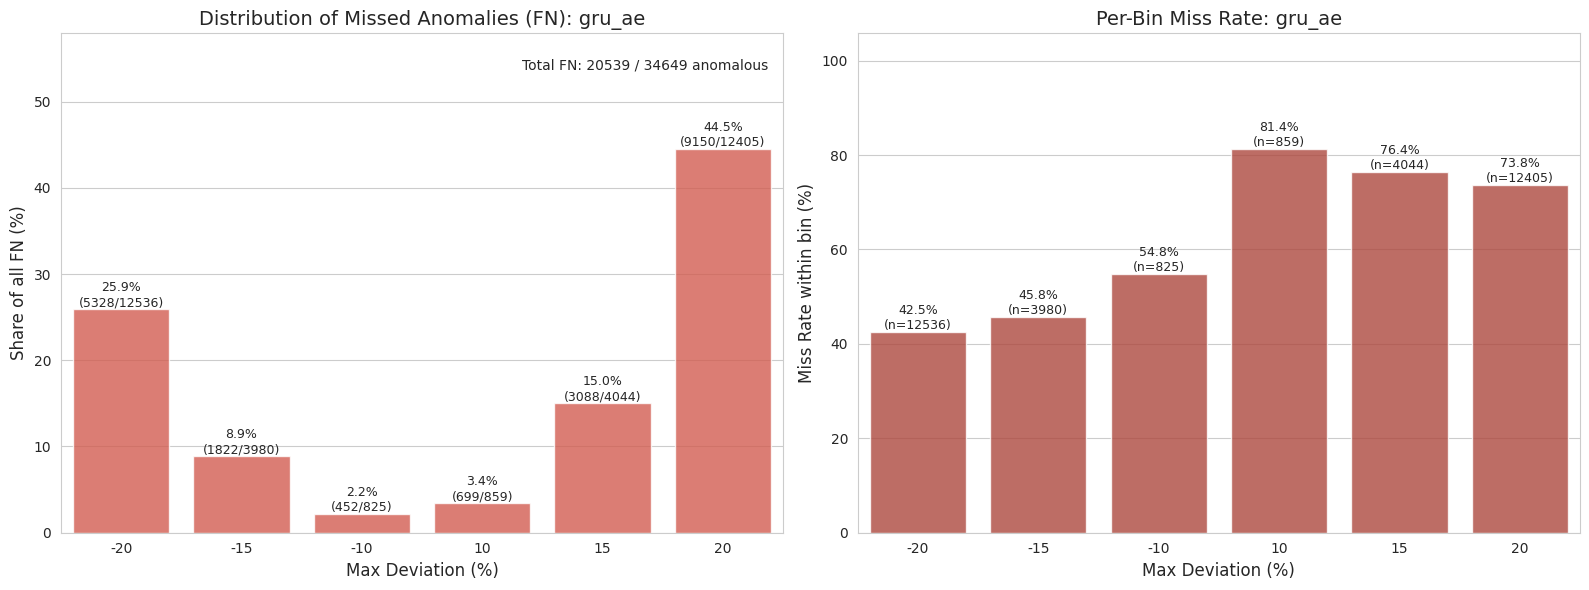


--- [ gru_ae ] Error by Variation Count ---


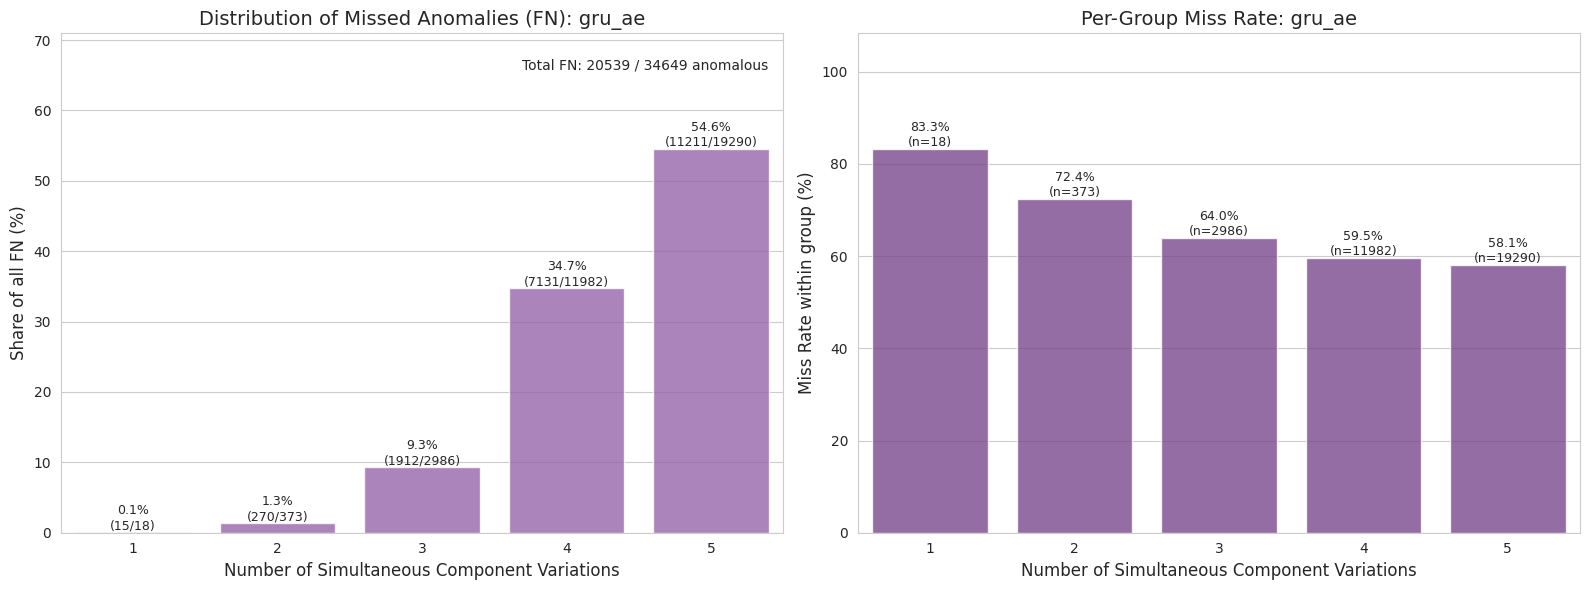


--- [ gru_ae ] Prediction Score Distribution ---


/mnt/e/Work/UC3M/UC3M/fault_converters/src/visualization/analysis.py:947: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


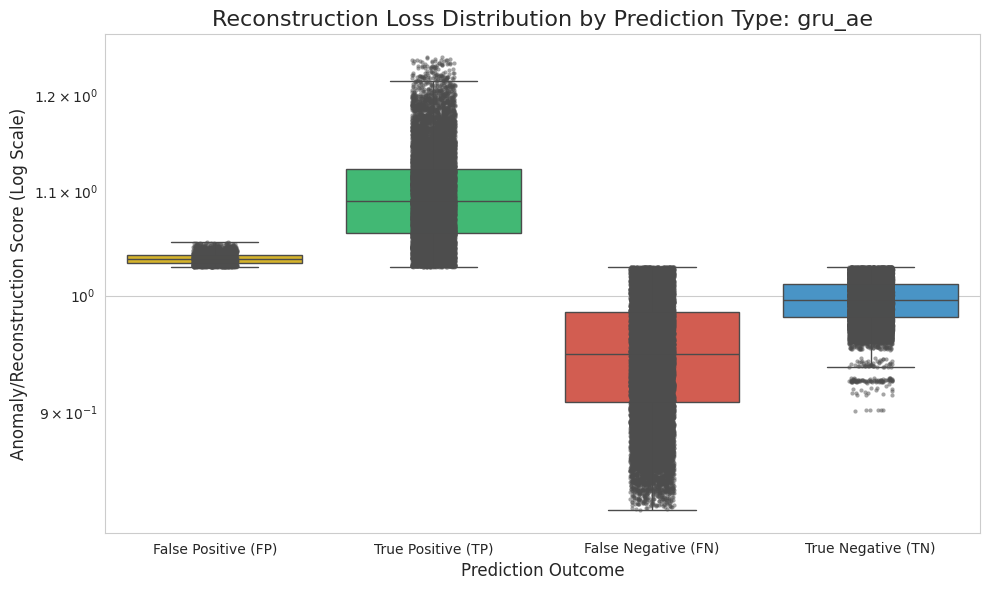


--- [ gru_ae ] Error Scatter Profile ---


<Figure size 640x480 with 0 Axes>

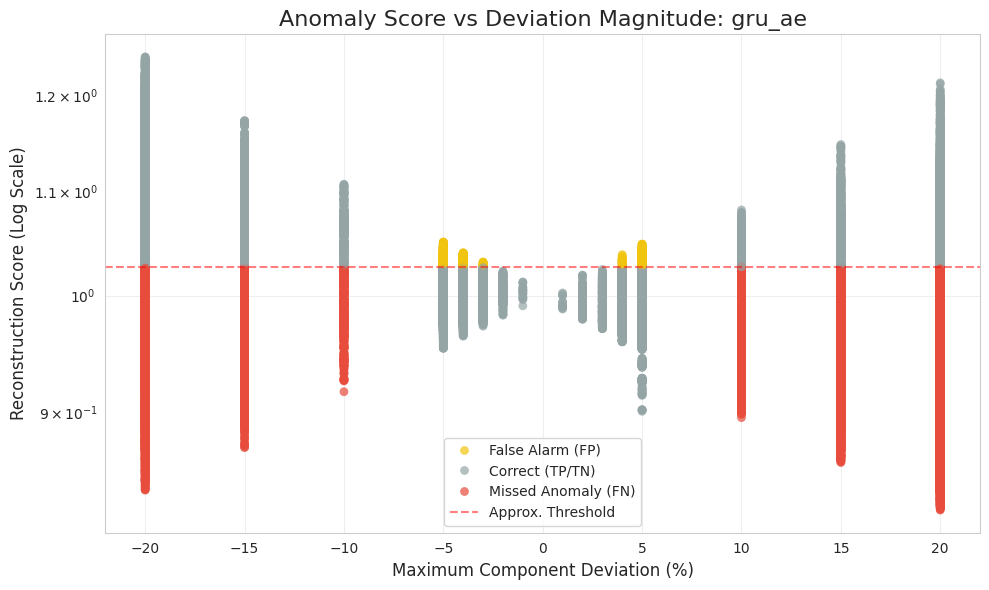


##############################
# DIAGNOSING: LSTM_AE
##############################

--- [ lstm_ae ] Component Error Analysis ---


<Figure size 640x480 with 0 Axes>

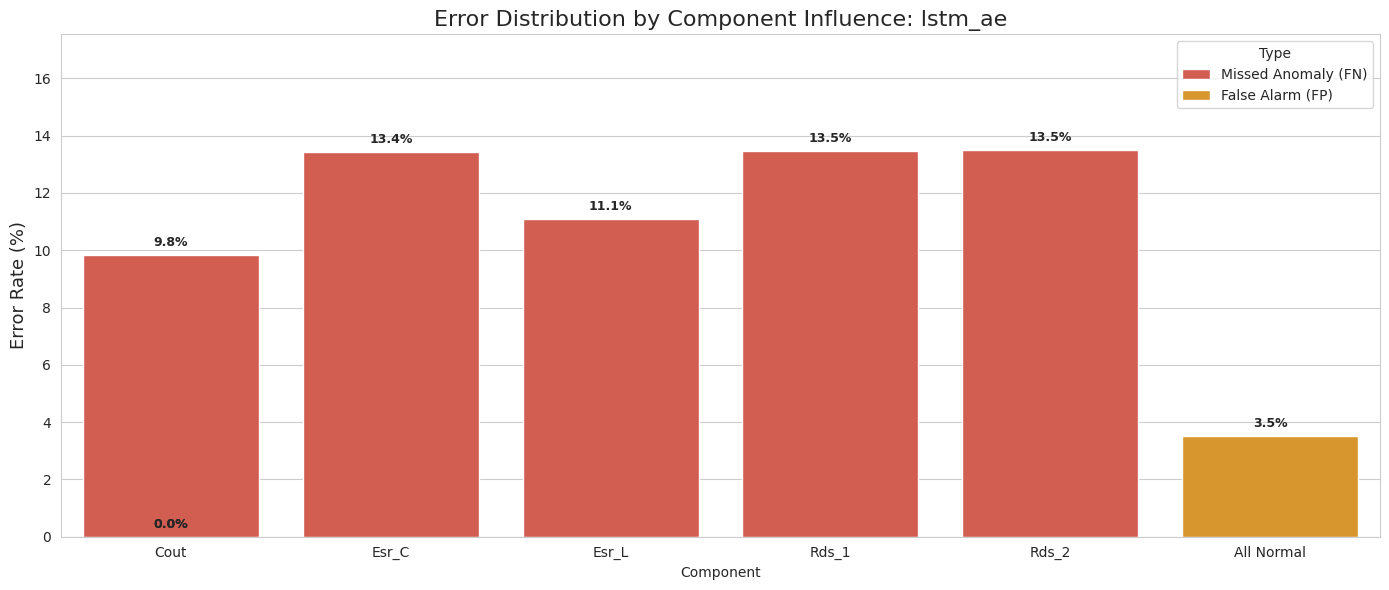


--- [ lstm_ae ] Error by Deviation Magnitude ---


<Figure size 640x480 with 0 Axes>

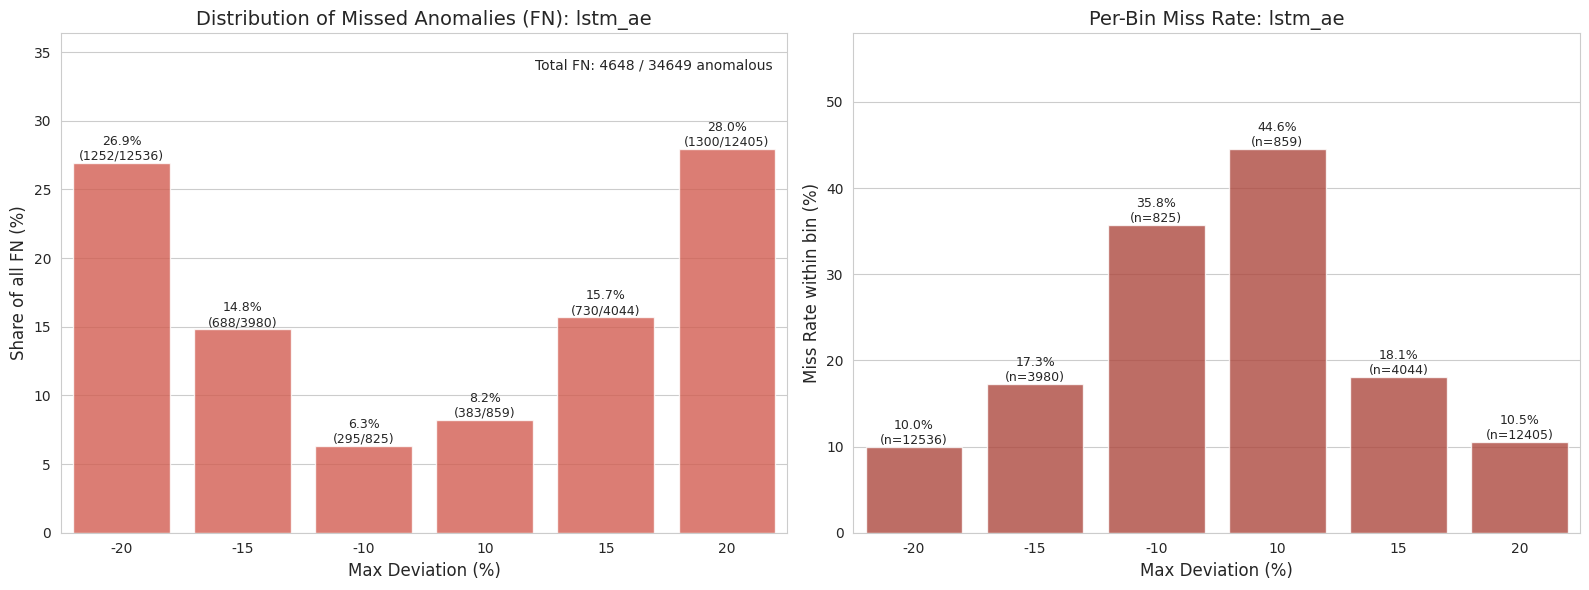


--- [ lstm_ae ] Error by Variation Count ---


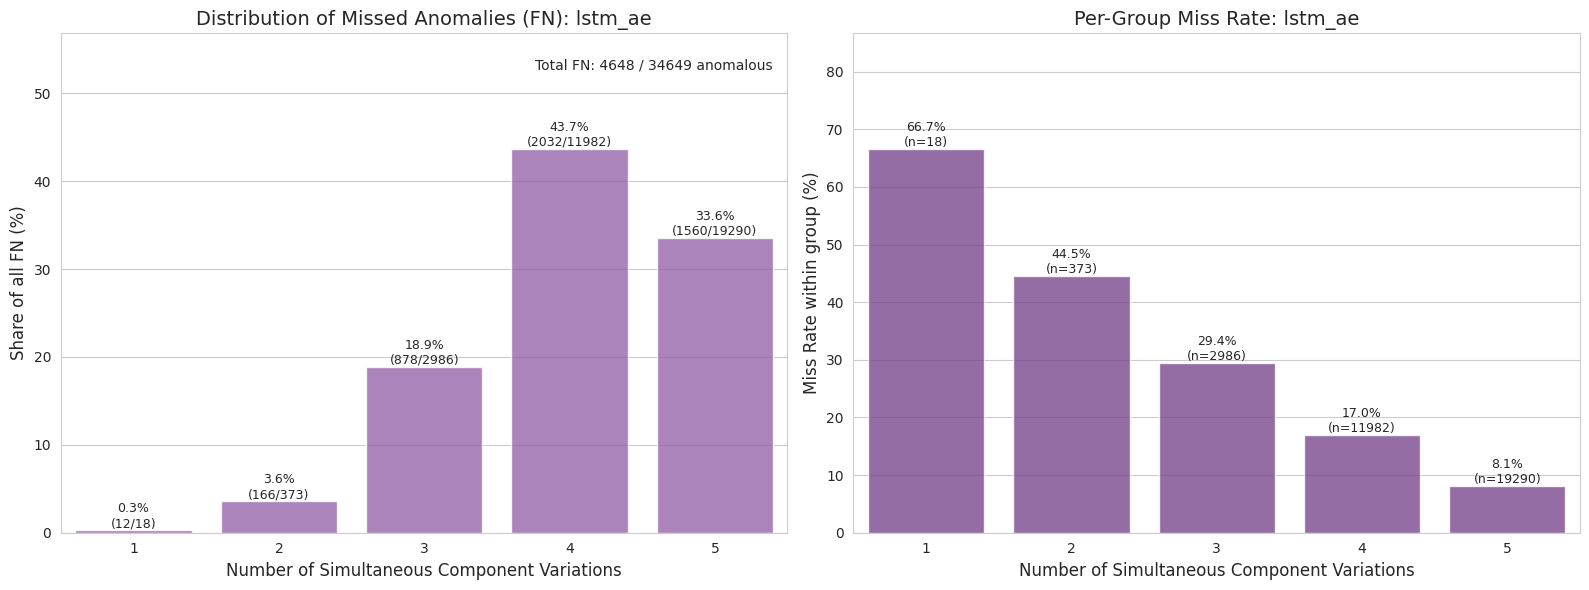


--- [ lstm_ae ] Prediction Score Distribution ---


/mnt/e/Work/UC3M/UC3M/fault_converters/src/visualization/analysis.py:947: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


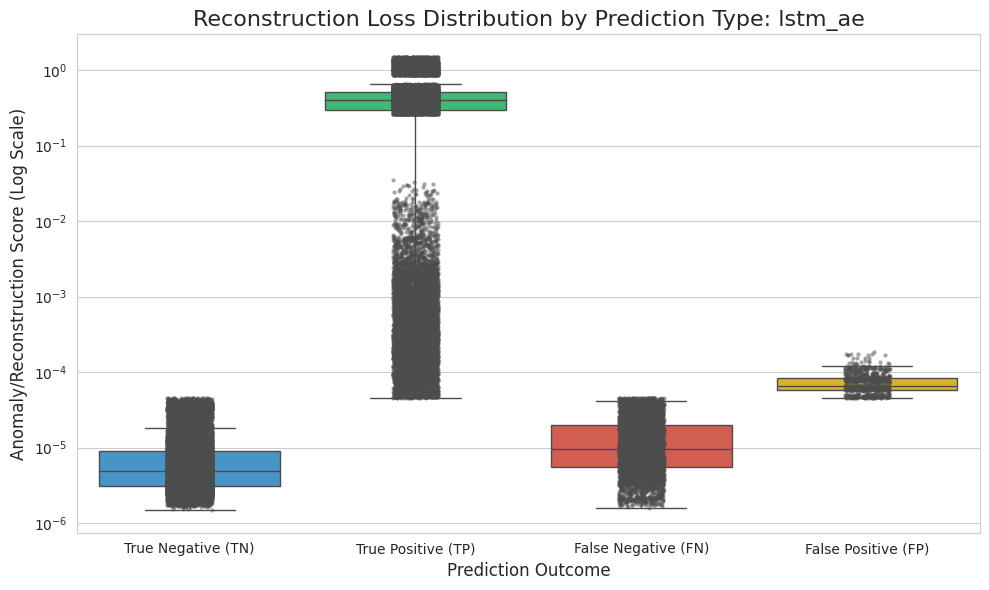


--- [ lstm_ae ] Error Scatter Profile ---


<Figure size 640x480 with 0 Axes>

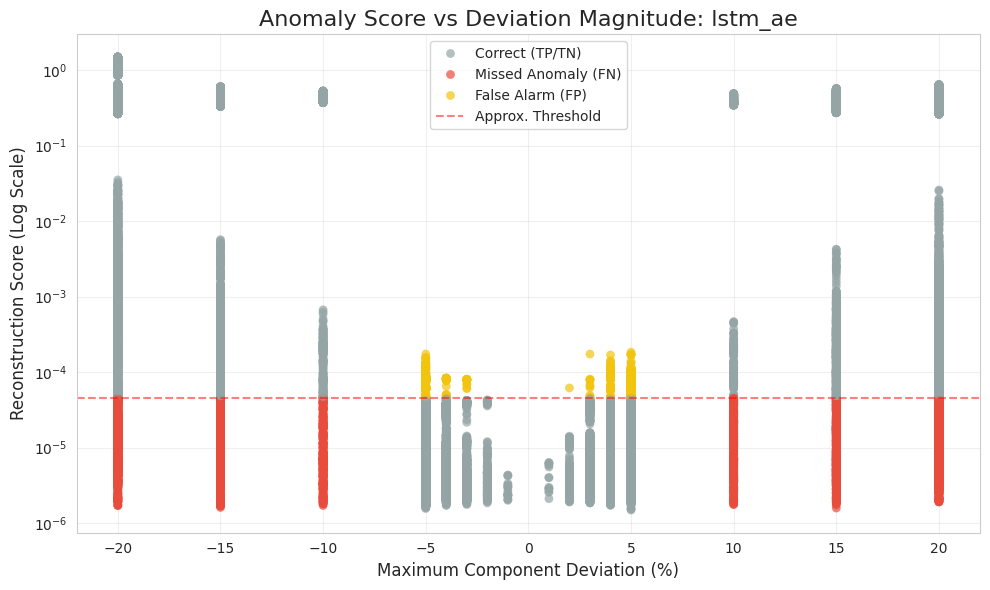


##############################
# DIAGNOSING: MLP_AE
##############################

--- [ mlp_ae ] Component Error Analysis ---


<Figure size 640x480 with 0 Axes>

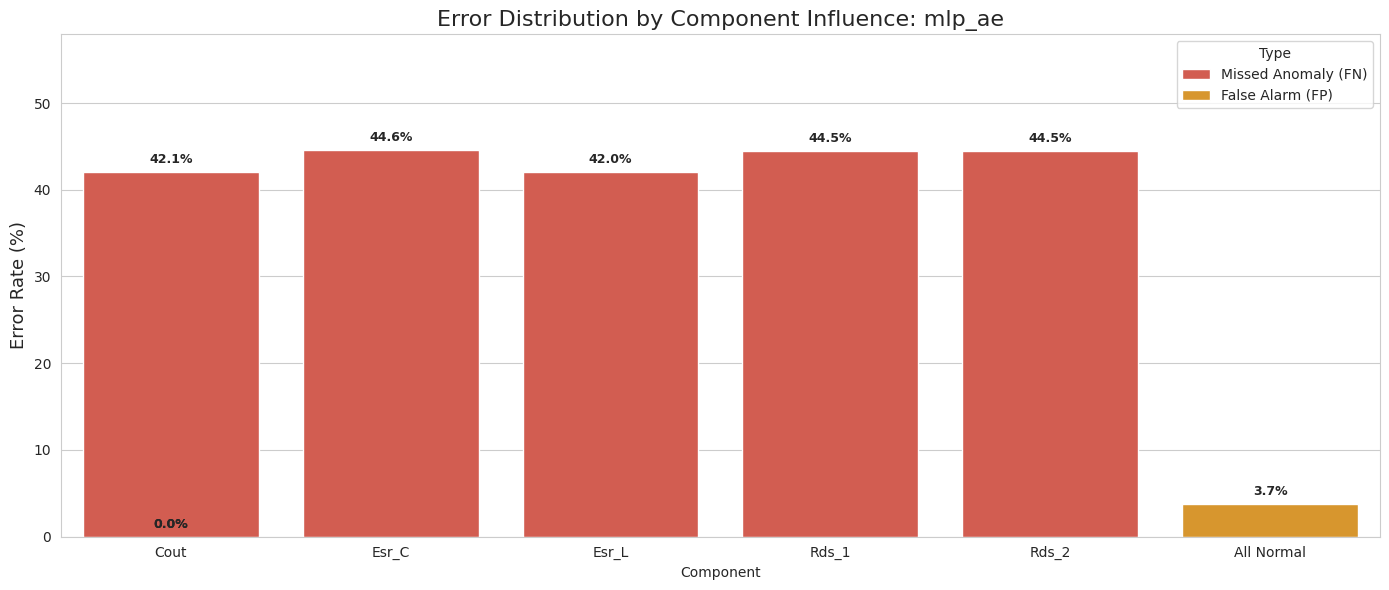


--- [ mlp_ae ] Error by Deviation Magnitude ---


<Figure size 640x480 with 0 Axes>

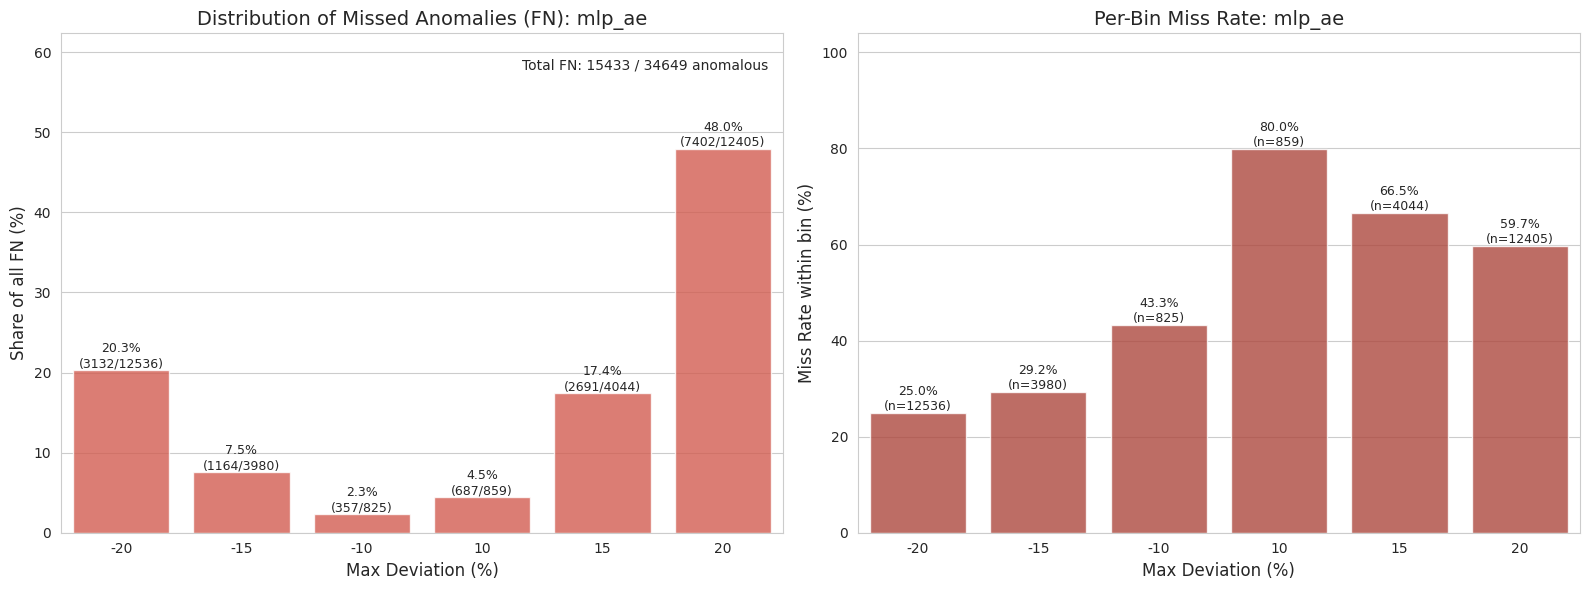


--- [ mlp_ae ] Error by Variation Count ---


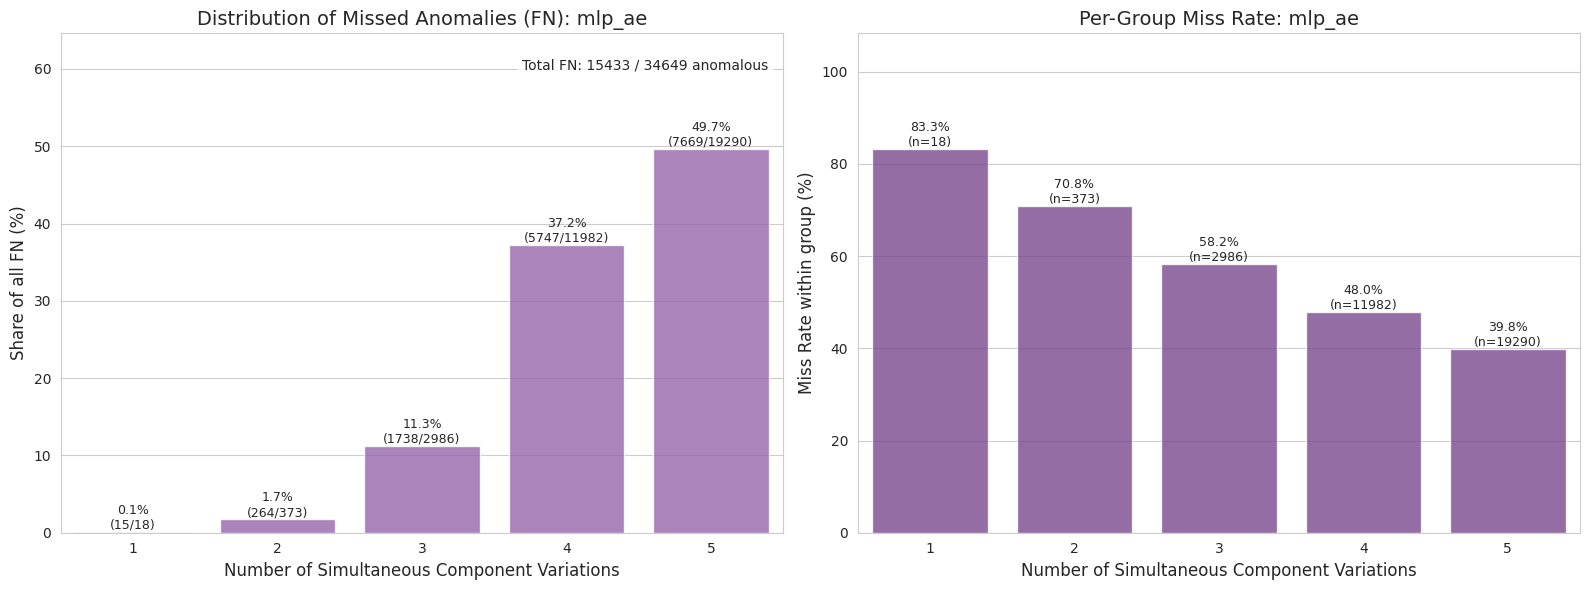


--- [ mlp_ae ] Prediction Score Distribution ---


/mnt/e/Work/UC3M/UC3M/fault_converters/src/visualization/analysis.py:947: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


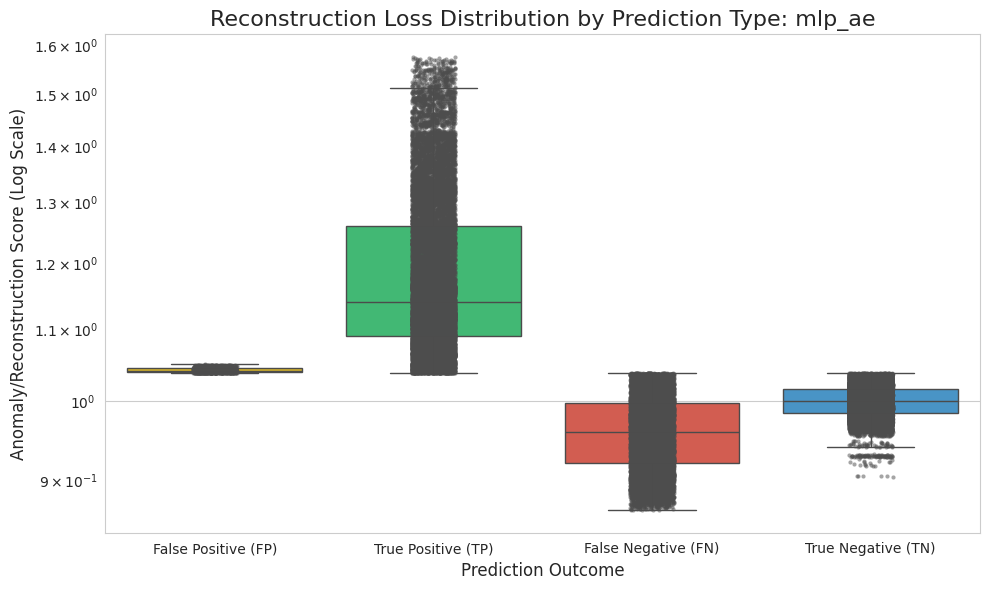


--- [ mlp_ae ] Error Scatter Profile ---


<Figure size 640x480 with 0 Axes>

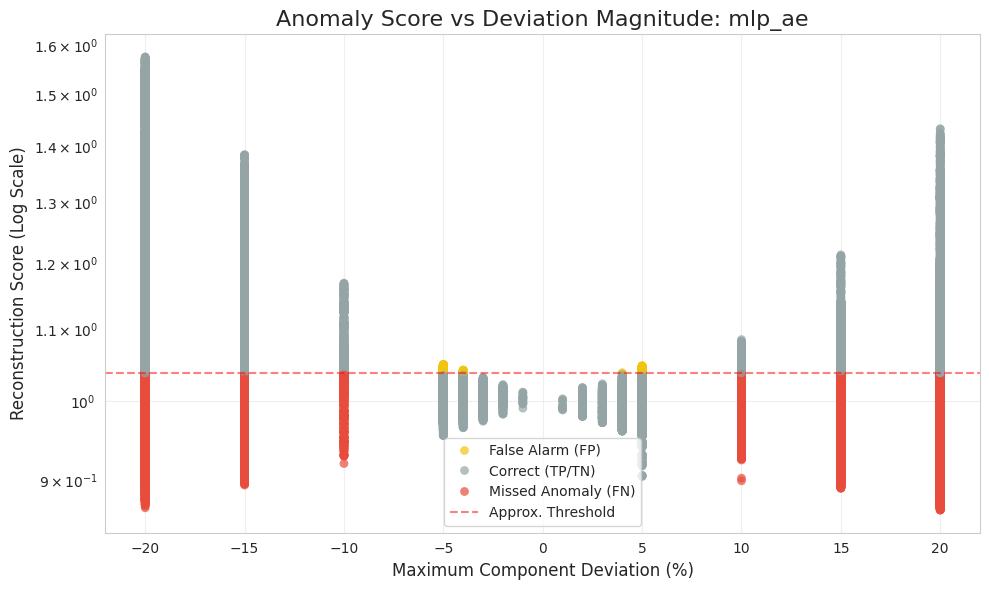


##############################
# DIAGNOSING: TRANSFORMER_AE
##############################

--- [ transformer_ae ] Component Error Analysis ---


<Figure size 640x480 with 0 Axes>

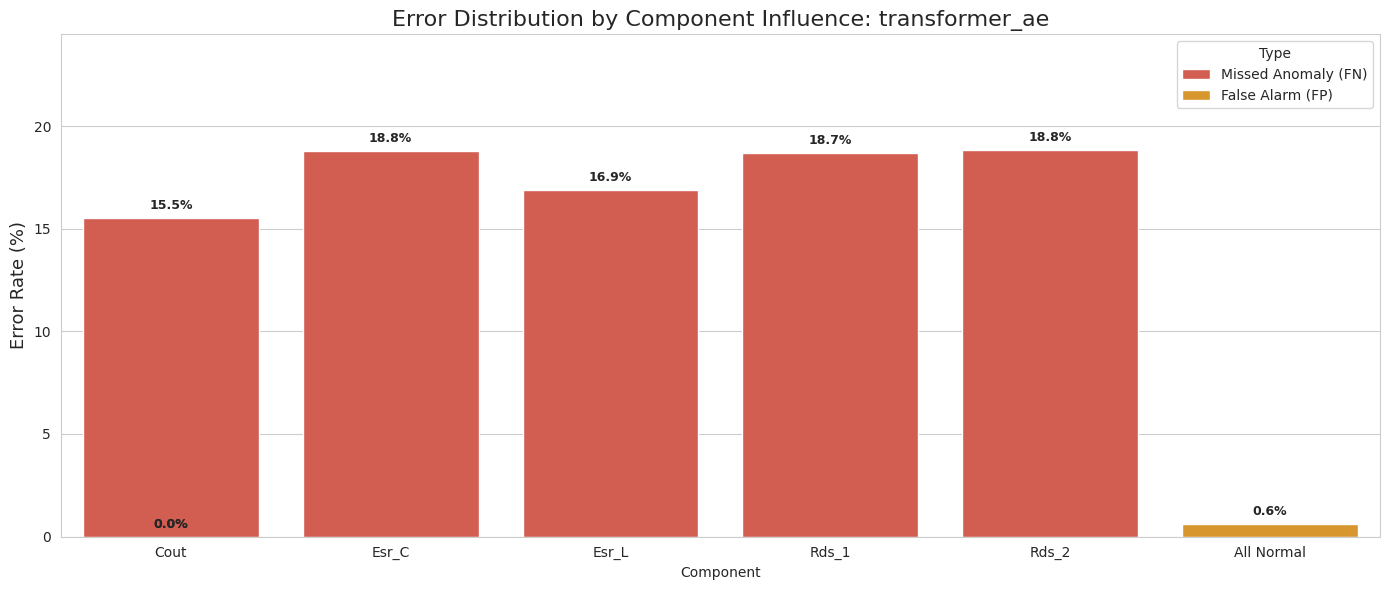


--- [ transformer_ae ] Error by Deviation Magnitude ---


<Figure size 640x480 with 0 Axes>

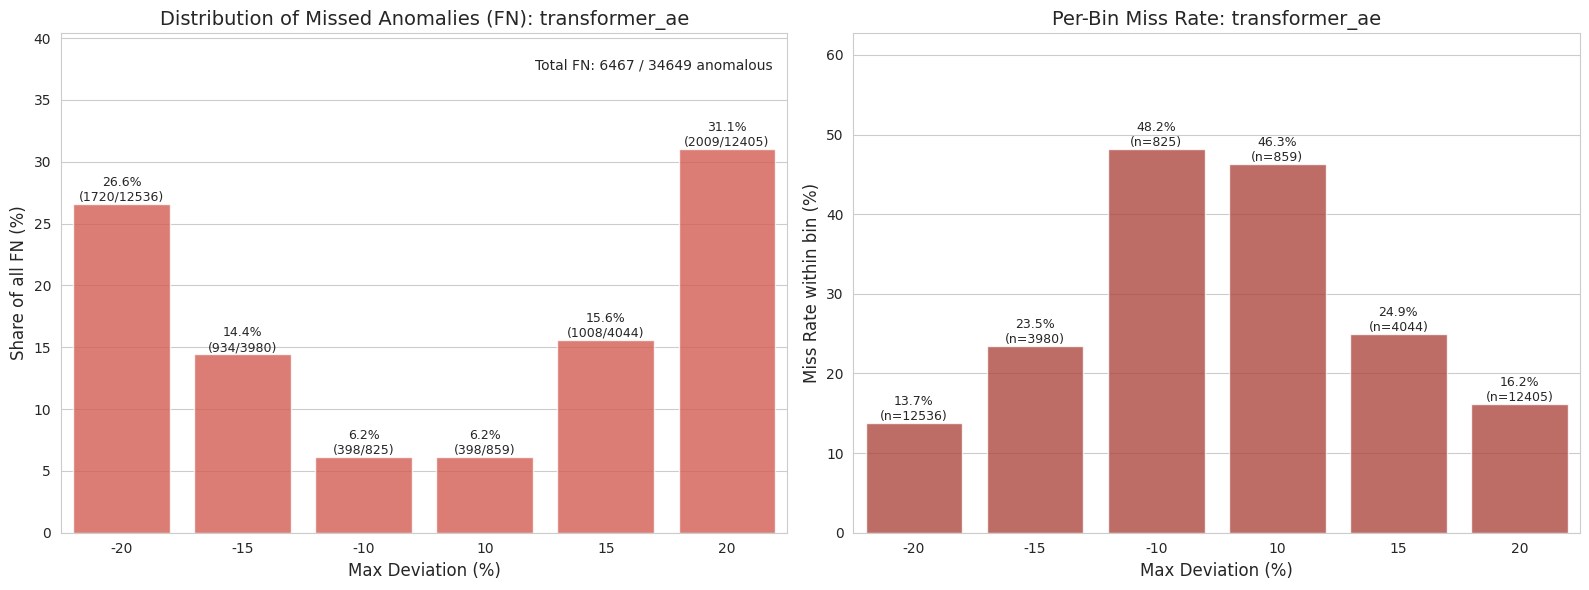


--- [ transformer_ae ] Error by Variation Count ---


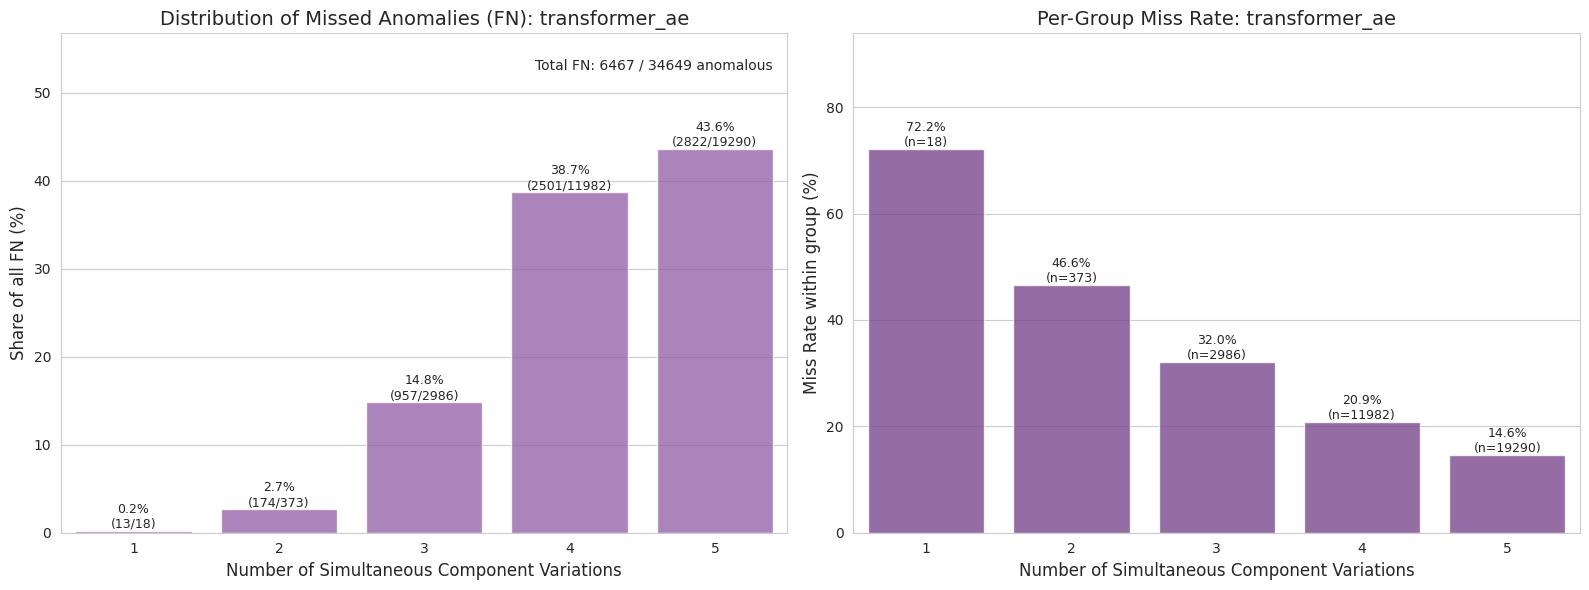


--- [ transformer_ae ] Prediction Score Distribution ---


/mnt/e/Work/UC3M/UC3M/fault_converters/src/visualization/analysis.py:947: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


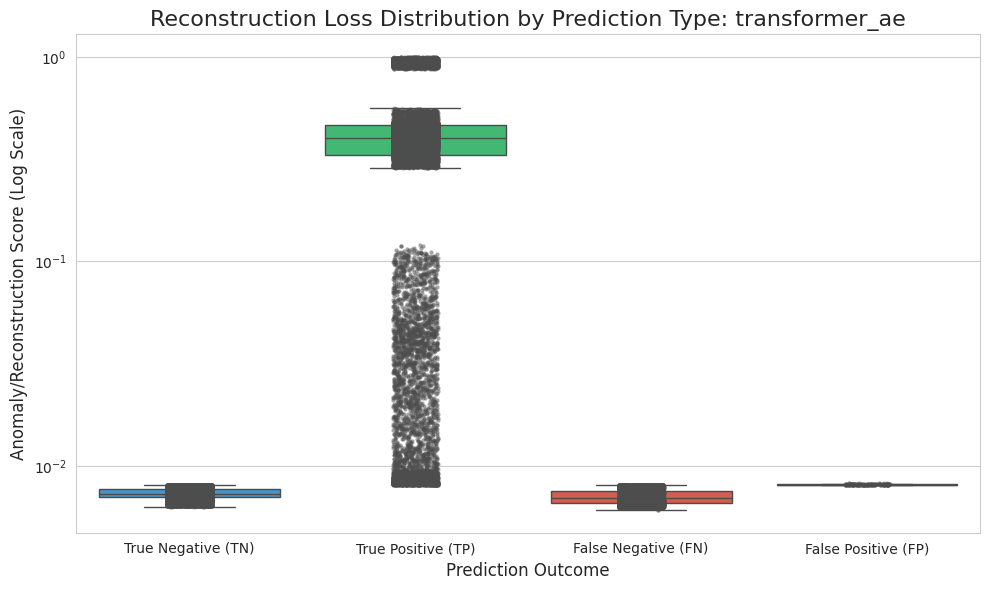


--- [ transformer_ae ] Error Scatter Profile ---


<Figure size 640x480 with 0 Axes>

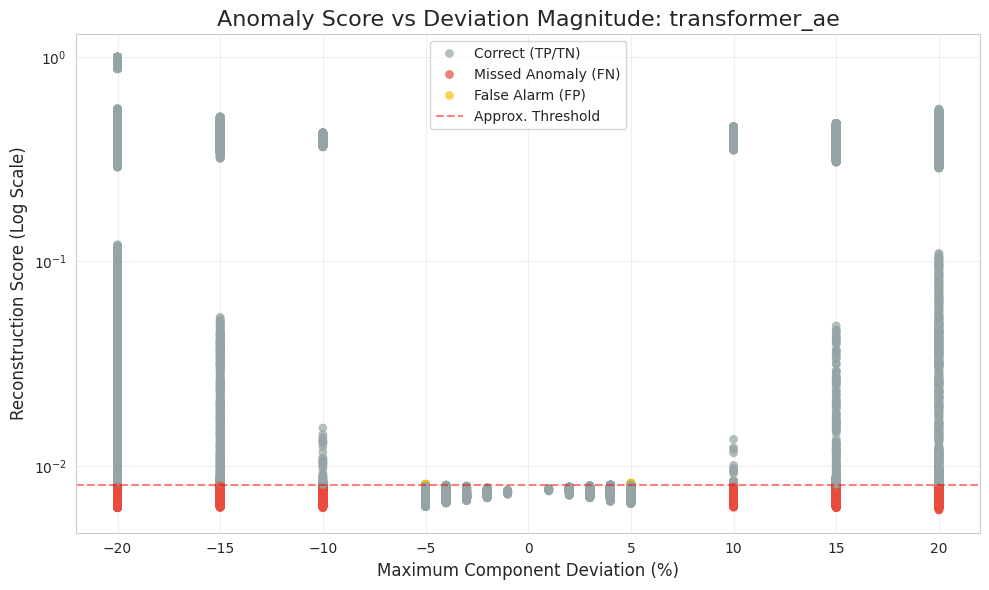


##############################
# DIAGNOSING: VAE
##############################

--- [ vae ] Component Error Analysis ---


<Figure size 640x480 with 0 Axes>

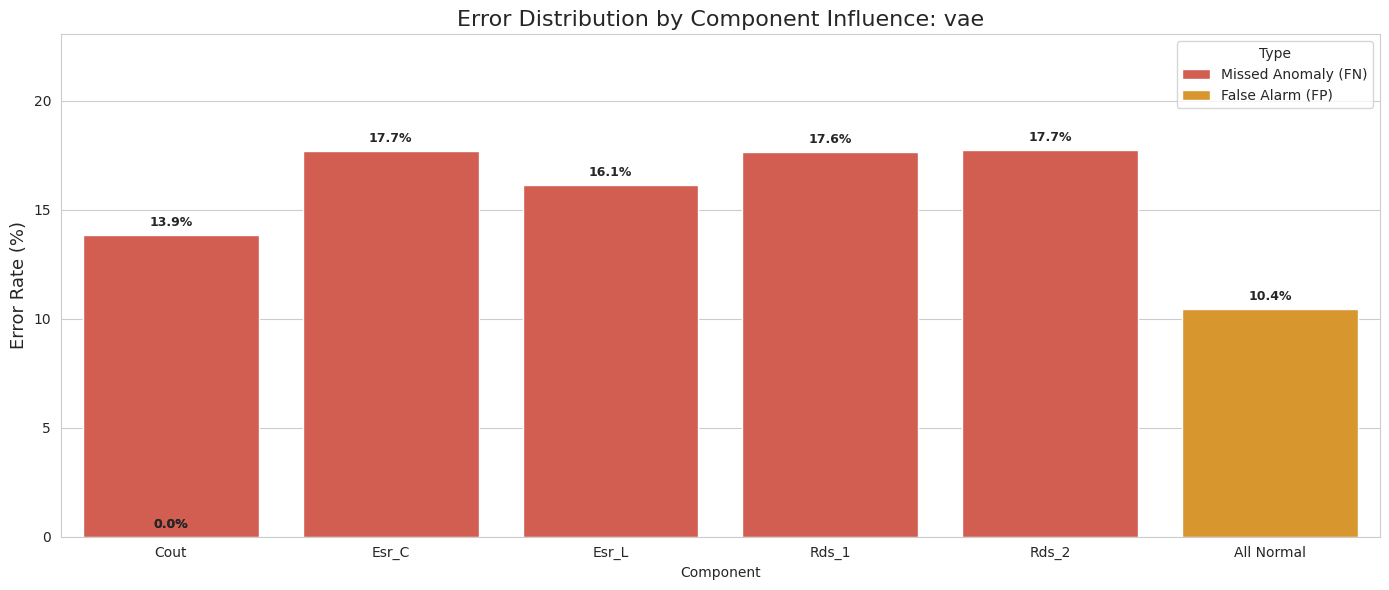


--- [ vae ] Error by Deviation Magnitude ---


<Figure size 640x480 with 0 Axes>

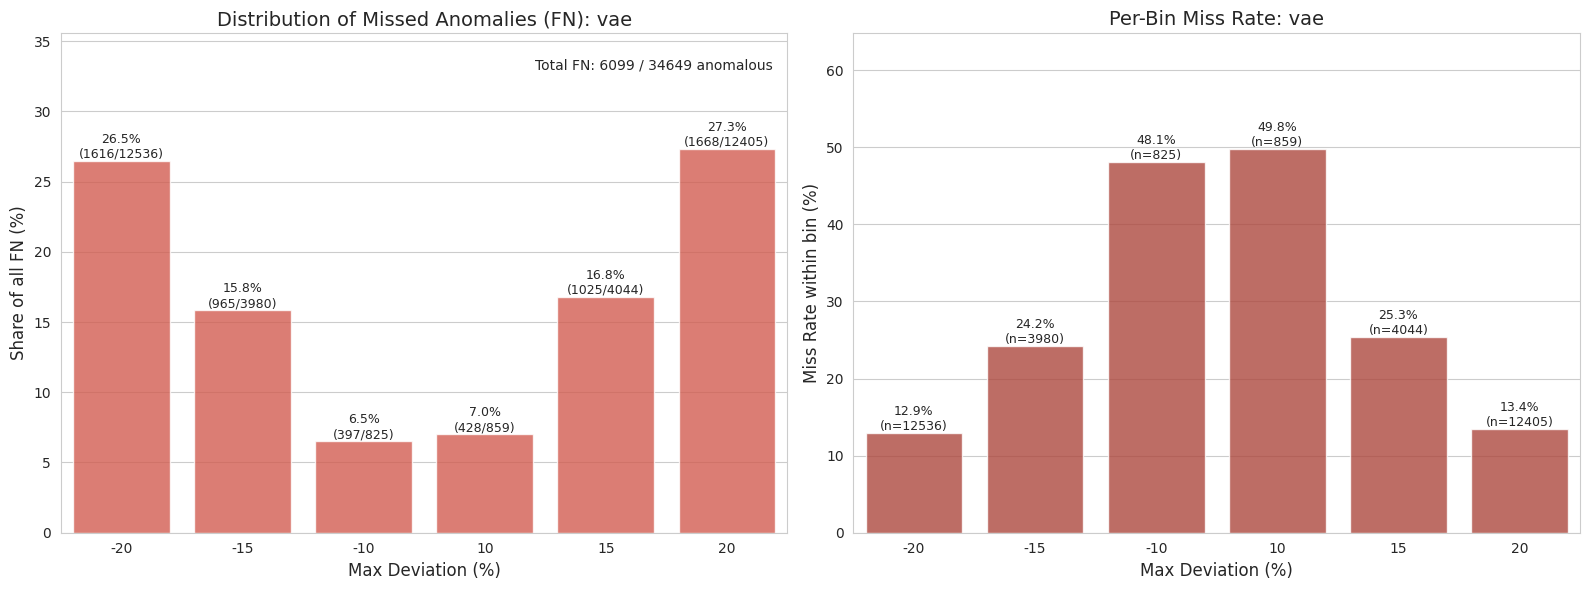


--- [ vae ] Error by Variation Count ---


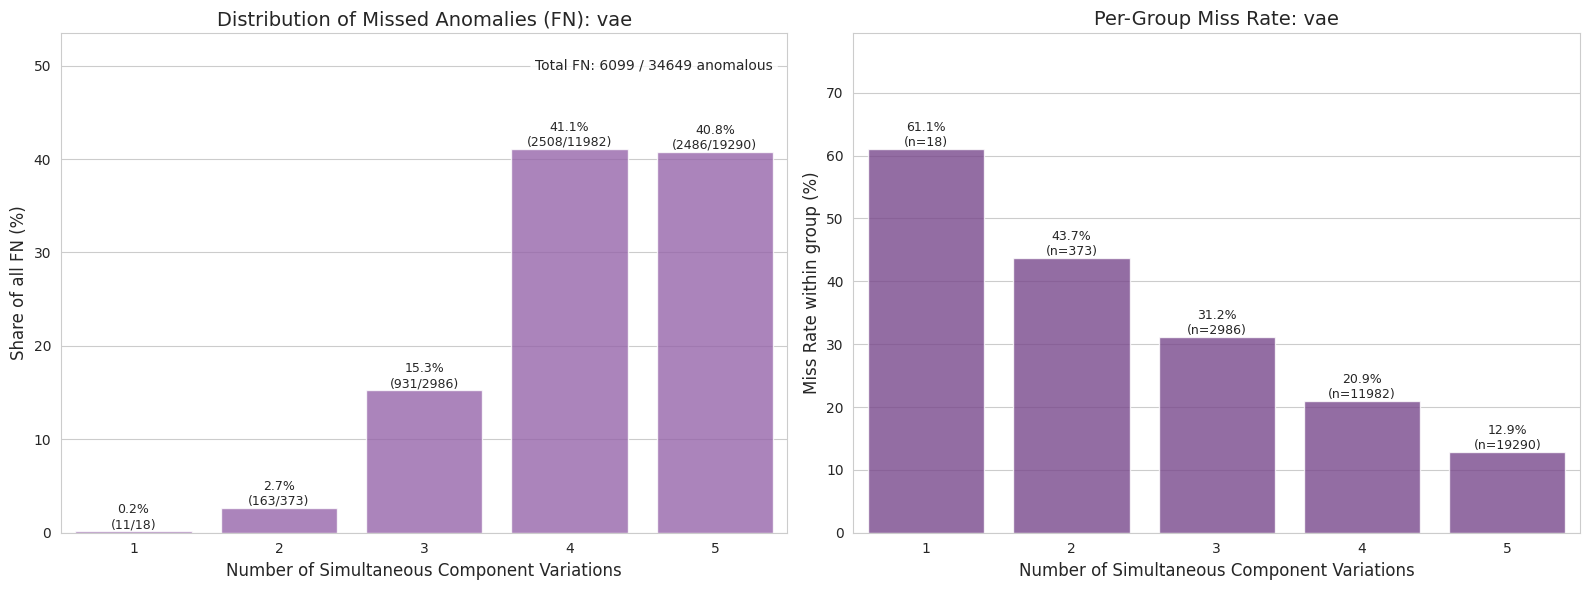


--- [ vae ] Prediction Score Distribution ---


/mnt/e/Work/UC3M/UC3M/fault_converters/src/visualization/analysis.py:947: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


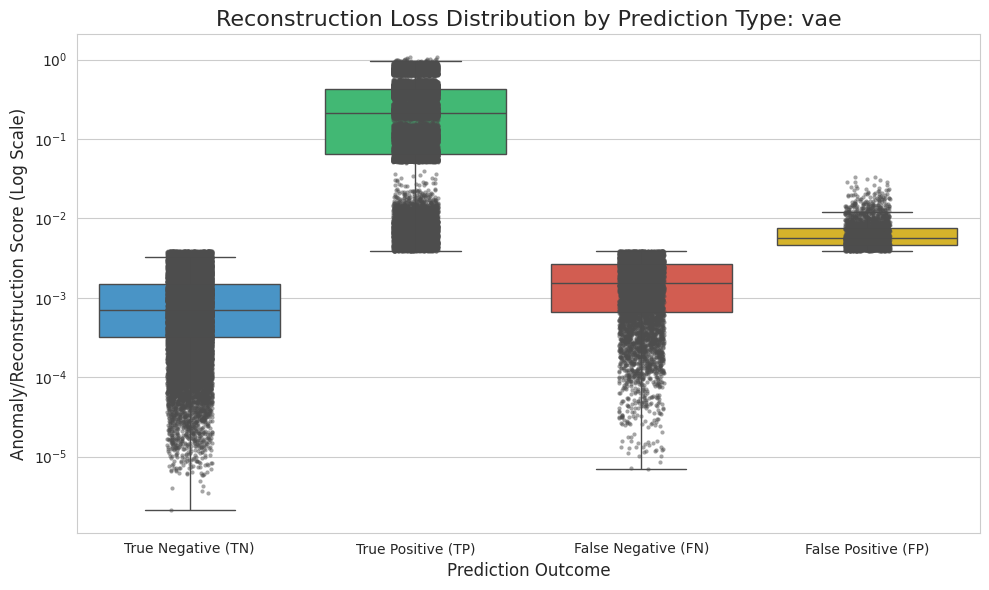


--- [ vae ] Error Scatter Profile ---


<Figure size 640x480 with 0 Axes>

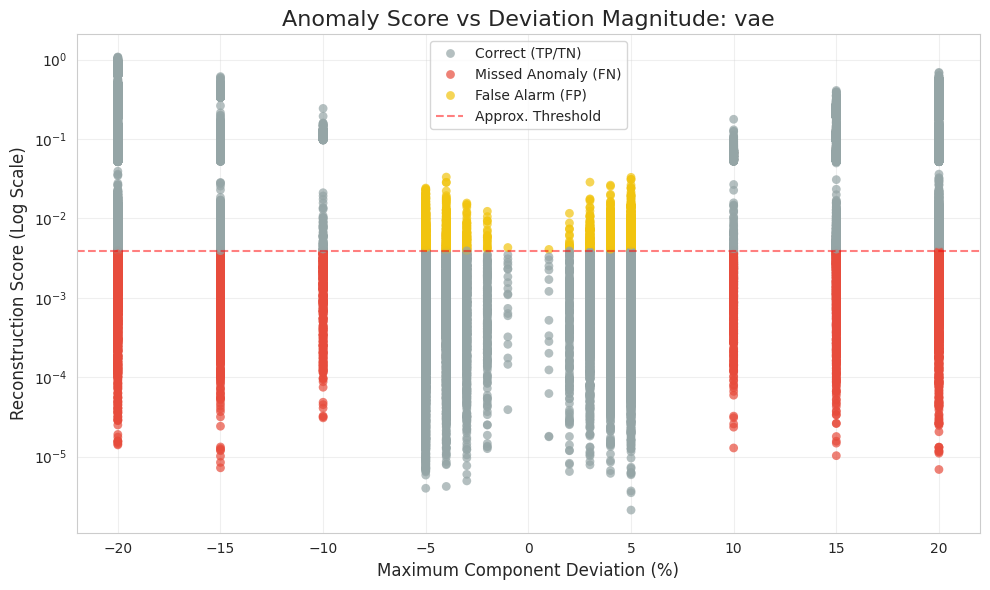

<Figure size 640x480 with 0 Axes>

In [5]:
import pandas as pd

print("Scanning for all trained results...")
all_results = list(EXPERIMENTS_DIR.rglob("test_results.csv"))

if not all_results:
    print(
        "No test_results.csv files found. Run evaluation script or wait for training to complete."
    )
else:
    for results_path in all_results:
        model_name = results_path.parent.name
        print(f"\n{'#' * 30}\n# DIAGNOSING: {model_name.upper()}\n{'#' * 30}")

        test_results = pd.read_csv(results_path)

        # 4.1 Component-wise Error breakdown
        print(f"\n--- [ {model_name} ] Component Error Analysis ---")
        plot_component_error_analysis(test_results, model_name=model_name)

        # 4.2 Error by deviation magnitude
        print(f"\n--- [ {model_name} ] Error by Deviation Magnitude ---")
        plot_error_by_deviation_magnitude(test_results, model_name=model_name)

        # 4.3 Error by number of variations
        print(f"\n--- [ {model_name} ] Error by Variation Count ---")
        plot_error_by_variation_count(test_results, model_name=model_name)

        # 4.4 Prediction Score Distributions
        print(f"\n--- [ {model_name} ] Prediction Score Distribution ---")
        plot_prediction_score_distribution(test_results, model_name=model_name)

        # 4.5 Error Scatter Plot
        print(f"\n--- [ {model_name} ] Error Scatter Profile ---")
        plot_error_scatter(test_results, model_name=model_name)